# Keypoint-модель бедра v2 (большой вертел, шейка бедра, седалищная кость)

Переработка `train_hip_keypoints.ipynb` по рецепту, который сработал для гребня таза (`train_pelvis_crest.ipynb`):

- **Все снимки зеркалятся в одну сторону.** `image_right` отражается по горизонтали (снимок и точки), боковая сторона бедра всегда справа
  (как рис. 6 ТЗ). Проверено по данным: после этого порядок точек слева направо «седалищная — шейка — вертел» выполняется на 149 из 149 снимков.
  Раньше в обучении были обе ориентации плюс случайный `HorizontalFlip` — модели приходилось выучивать зеркальные картинки отдельно на ~150 снимках.
- **Backbone — не `resnet18.a1_in1k`** (нестандартный рецепт «ResNet strikes back»), а сравнение трёх готовых весов: ConvNeXt-Tiny (ImageNet-22k),
  ResNet18 (1 млрд картинок) и классический ResNet18 (torchvision). Для таза ConvNeXt-Tiny оказался заметно лучше.
- **Маска допустимой области для каждой точки.** Вне зоны, где точка вообще может находиться (границы из данных, с запасом на аугментацию),
  логит heatmap принудительно -20 — пик не может уйти на таз, диафиз или на другую точку.
- **Чистое фото и точка только на кости.** Математическая маска кости накладывается на вход (всё, что не кость — шум, дымка по краям, лишние ткани — обнуляется), а пик heatmap
  разрешён только на кости. Точка «в воздухе» невозможна (раньше такое случалось: жёлтый `С` уходил в пустую зону, а голова присутствия при этом давала 0.99).
- **Голова присутствия** («точка есть / нет») отдельно от положения: решение видна/не видна принимается по ней, а не по высоте пика heatmap.
- **Разморожен backbone** (шаг 1e-4 вместо 1e-5 при заморозке до layer2).
- **Один прогон вместо кросс-валидации:** обучение на фолдах, кроме `VAL_FOLD` и `TEST_FOLD`; ранняя остановка и порог по `VAL_FOLD`; честный `TEST_FOLD`.

## Невидимые точки

В разметке их единицы: большой вертел — 1, шейка бедра — 1, седалищная кость — 4 (из 153 снимков). Строки с NaN не выбрасываются — это обучающий сигнал.
Так как естественных негативов почти нет, «невидимость» имитируется **закрытием чёрным** (полоса, прямоугольник или косой срез накрывают реальную точку) —
`expand_with_crop_duplicates`, 30% дублей, детерминированно, и так же проверяется отдельной синтетической оценкой.

## Перед запуском

`training_package` (`images/`) + `hip_keypoints_manifest.csv`.

In [50]:
!pip install -q albumentations timm scikit-learn

In [51]:
import os
import random
import math

import numpy as np
import pandas as pd
import cv2
import albumentations as A
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm

## Воспроизводимость: seed + детерминизм

In [52]:
SEED = 42


def set_full_determinism(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_full_determinism(SEED)


def worker_init_fn(worker_id: int) -> None:
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def make_generator(seed: int = SEED) -> torch.Generator:
    g = torch.Generator()
    g.manual_seed(seed)
    return g

## Конфигурация

In [53]:
# --- ПРАВЬТЕ ПОД СВОЮ СРЕДУ ---
IMAGES_DIR = "/kaggle/input/datasets/cgvhbjmk/dxa-data/training_package/images"
KEYPOINTS_MANIFEST_PATH = "/kaggle/input/datasets/cgvhbjmk/dxa-data/training_package/hip_keypoints_manifest.csv"
OUTPUT_DIR = "./outputs_hip_keypoints_v2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMAGE_SIZE = 224
BATCH_SIZE = 8
NUM_EPOCHS = 60
EARLY_STOPPING_PATIENCE = 10
HEAD_LR = 1e-3
BACKBONE_LR = 1e-4  # было 1e-5 при заморозке до layer2 включительно — признаки почти не подстраивались под рентген
TEST_FOLD = 4  # честный отложенный тест (фолд из Step 1)
VAL_FOLD = 3   # валидация: ранняя остановка и калибровка порога присутствия
NUM_WORKERS = 2

KEYPOINT_NAMES = ["большой_вертел", "шейка_бедра", "седалищная_кость"]
KEYPOINT_LETTERS = ["В", "Ш", "С"]
KEYPOINT_COLORS = ["red", "cyan", "yellow"]
HEATMAP_SIGMA = 6.0  # пикселей, в масштабе 224x224

# Области, где каждая точка может находиться, (x0, x1, y0, y1) в масштабе 224x224 в КАНОНИЧЕСКОМ кадре (боковая сторона бедра справа).
# Взяты из данных: минимум/максимум по всем 149 снимкам с аугментацией (поворот +-15, масштаб 0.9-1.1, сдвиг 5%) плюс запас ~10 px:
#   большой_вертел    x 94..194, y 46..144   шейка_бедра   x 56..158, y 53..139   седалищная_кость   x 6..101, y 67..183
REGIONS = [(84, 204, 36, 154), (46, 168, 42, 150), (0, 112, 56, 194)]

# Backbone — обычные картинки, не рентген (готовые веса из timm). Замораживается только самый ранний слой
# (общие края/текстуры), имена параметров зависят от семейства.
#   convnext_tiny.fb_in22k_ft_in1k  — ImageNet-22k (14 млн картинок, 22 тыс. классов) -> ImageNet-1k
#   resnet18.fb_swsl_ig1b_ft_in1k   — тот же ResNet18, но предобучен на 1 млрд картинок, затем дообучен на ImageNet
#   resnet18.tv_in1k                — классические веса torchvision
BACKBONES = {
    "convnext_tiny.fb_in22k_ft_in1k": ("stem", "stages_0"),
    "resnet18.fb_swsl_ig1b_ft_in1k": ("conv1", "bn1", "layer1"),
    "resnet18.tv_in1k": ("conv1", "bn1", "layer1"),
    "resnet18.a1_in1k": ("conv1", "bn1", "layer1"),  # был в старом ноутбуке
}
BACKBONE_CANDIDATES = [  # обучаются по очереди и сравниваются в конце. По умолчанию только победитель (на тазе и на бедре ConvNeXt лучше по положению точек);
    "convnext_tiny.fb_in22k_ft_in1k",  # чтобы сравнить снова, добавьте "resnet18.fb_swsl_ig1b_ft_in1k" и/или "resnet18.tv_in1k"
]
PRETRAINED_BACKBONE = True
# Маска кости (математика, см. bone_mask ниже) накладывается на вход модели: всё, что не кость (шум, дымка по краям, лишние ткани), обнуляется —
# модель учится на "чистом" фото. Дополнительно пик heatmap разрешён только на кости (плюс BONE_MASK_OUTPUT_DILATE_PX), так что точка
# "в воздухе" невозможна. Размеченные точки лежат внутри маски на 99-100% (r=2 px, масштаб 224), запас входа 3 px + выхода 1 px.
USE_BONE_MASK_INPUT = True
BONE_MASK_INPUT_DILATE_PX = 3   # на сколько px маска расширяется перед обнулением фона (контекст у края кости)
BONE_MASK_OUTPUT_DILATE_PX = 1  # допуск пика heatmap за край маски
PRESENCE_LOSS_WEIGHT = 0.2  # вес BCE головы "точка есть/нет" относительно лосса heatmap (угадан)
VISIBILITY_THRESHOLD = 0.9  # используется только для точности присутствия в логе обучения; итоговый порог для каждого
                            # backbone выбирается в ячейке калибровки (chosen_threshold)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## Аугментация

Геометрия через `A.Compose(..., keypoint_params=...)` (albumentations сама пересчитывает точки). **Без `HorizontalFlip`:** все снимки уже приведены к одной
стороне, зеркальное отражение создало бы «неправильную» анатомию, которой на инференсе не будет.
`CoarseDropout` не используется — риск закрасить именно ту точку, которую надо найти.

In [54]:
def clahe(image: np.ndarray) -> np.ndarray:
    return cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8)).apply(image)


def build_train_transform(image_size=IMAGE_SIZE) -> A.Compose:
    return A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.8),
        A.RandomGamma(gamma_limit=(70, 130), p=0.5),
        A.OneOf([
            A.GaussNoise(std_range=(0.02, 0.08), p=1.0),
            A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
        ], p=0.4),
        A.Affine(scale=(0.9, 1.1), translate_percent=(0.0, 0.05), rotate=(-15, 15), fit_output=False, p=0.7),
        A.LongestMaxSize(max_size=image_size),
        A.PadIfNeeded(min_height=image_size, min_width=image_size, border_mode=cv2.BORDER_CONSTANT, fill=0),
    ], keypoint_params=A.KeypointParams(format="xy", remove_invisible=False), seed=SEED)


def build_eval_transform(image_size=IMAGE_SIZE) -> A.Compose:
    return A.Compose([
        A.LongestMaxSize(max_size=image_size),
        A.PadIfNeeded(min_height=image_size, min_width=image_size, border_mode=cv2.BORDER_CONSTANT, fill=0),
    ], keypoint_params=A.KeypointParams(format="xy", remove_invisible=False))

## Маска кости (математика)

Порог относительно фона, ядро — Otsu (наибольшая светлая область), достраивается до кости низкой плотности; то же, что `bone_mask_full` в `hip_roi_margins.py`, но без зависимостей
(ноутбук должен работать на Kaggle). Маска считается по снимку в масштабе 224×224 уже после аугментации и закрытия — ровно так же, как будет на инференсе.
Проверено на разметке: размеченные точки лежат внутри маски на 100% (вертел, седалищная) и 98-99% (шейка), с запасом 2 px — 99.3-100%.

**Эндопротез.** У снимков с металлом обычная маска рвётся (тёмный ореол вокруг чашки и ножки отрывает кость от ядра). Они определяются математически детектором металла из проекта
(`detect_implant`, тот же алгоритм, что в `services/region_classifier/implant_detect.py`: пятно насыщения до 255 почти без разброса, крупное — `blob`, тонкий стержень — `rod`) и получают
другую маску (`implant_bone_mask`): металл включается, разрывы замыкаются, внутренние дыры заполняются. В данных таких снимков 3 из 153.

In [55]:
BONE_INSIDE_RADIUS_PX = 2  # расширение проверки "внутри кости" (масштаб 224)
BONE_MIN_EXTRA_COMPONENT_PX = 150  # отдельные куски меньше этой площади (масштаб 224) отбрасываются как шум; после закрытия остаются небольшие куски кости
BONE_EXTRA_MIN_LEVEL_FRAC = 0.5    # отдельный кусок остаётся, только если он не тусклее этой доли яркости кости (дымка/мягкие ткани по краям тусклее)
# Эндопротез (металл): обычная маска рвётся (тёмный ореол вокруг чашки и ножки отрывает кость от ядра, яркий металл ломает порог). Для таких снимков маска
# другая: металл включается, разрывы замыкаются, внутренние дыры заполняются. Определение — детектор металла из проекта (services/region_classifier/implant_detect.py),
# его признак: жёсткое насыщение до 255 почти без разброса; работает по ИСХОДНОМУ кадру (до CLAHE), потому что опирается на точные значения пикселей.
# Проверен на данных: находит все 3 протеза из 153 снимков бедра и ни одного лишнего среди 99 снимков позвоночника.
IMPLANT_THRESH = 245        # порог кандидатных пятен (сам порог не решает — решают std и доля ровно 255)
IMPLANT_MIN_AREA_PX = 40
IMPLANT_MAX_STD = 2.0
IMPLANT_MIN_FRAC255 = 0.85
IMPLANT_BLOB_MIN_PX = 3000  # крупное пятно металла (головка, большая ножка) — форма не важна
IMPLANT_ROD_MIN_LEN_PX = 25  # тонкий стержень (ножка, винт) — важна форма
IMPLANT_ROD_MAX_WIDTH_PX = 22
IMPLANT_CLOSE_PX = 9        # ядро замыкания разрывов маски (эллипс, масштаб 224)
IMPLANT_SAT_DILATE_PX = 3   # металл расширяется, чтобы слиться с окружающей костью


def _segment_seed(img_u8: np.ndarray) -> np.ndarray:
    eq = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8)).apply(img_u8)
    blur = cv2.GaussianBlur(eq, (5, 5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((3, 3), np.uint8)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel)
    n, lab, st, _ = cv2.connectedComponentsWithStats(th, connectivity=8)
    if n <= 1:
        return th > 0
    return lab == 1 + np.argmax(st[1:, cv2.CC_STAT_AREA])


def detect_implant(img_u8: np.ndarray) -> tuple:
    # металл эндопротеза (services/region_classifier/implant_detect.py): пятно насыщения до 255 с малым разбросом; "blob" — крупное, "rod" — тонкий стержень
    sat = (img_u8 >= IMPLANT_THRESH).astype(np.uint8)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(sat, connectivity=8)
    for k in range(1, n):
        area = stats[k, cv2.CC_STAT_AREA]
        if area < IMPLANT_MIN_AREA_PX:
            continue
        ys, xs = np.where(labels == k)
        vals = img_u8[ys, xs].astype(np.float32)
        if vals.std() > IMPLANT_MAX_STD or (vals == 255).mean() < IMPLANT_MIN_FRAC255:
            continue
        if area >= IMPLANT_BLOB_MIN_PX:
            return True, "blob"
        (cx, cy), (w, h), angle = cv2.minAreaRect(np.column_stack([xs, ys]).astype(np.float32))
        if max(w, h) >= IMPLANT_ROD_MIN_LEN_PX and min(w, h) <= IMPLANT_ROD_MAX_WIDTH_PX:
            return True, "rod"
    return False, "none"


def fill_internal_holes(mask: np.ndarray) -> np.ndarray:
    # заполняет только ВНУТРЕННИЕ дыры (не связанные с внешним фоном); вокруг кадра добавляется рамка фона, чтобы области, упирающиеся в край кадра, дырами не считались
    inv = np.pad((~mask).astype(np.uint8), 1, constant_values=1)
    ff = np.zeros((inv.shape[0] + 2, inv.shape[1] + 2), np.uint8)
    cv2.floodFill(inv, ff, (0, 0), 2)
    return mask | (inv[1:-1, 1:-1] == 1)


def implant_bone_mask(img_u8: np.ndarray, mask: np.ndarray) -> np.ndarray:
    metal = cv2.dilate((img_u8 >= 250).astype(np.uint8), np.ones((IMPLANT_SAT_DILATE_PX, IMPLANT_SAT_DILATE_PX), np.uint8)) > 0
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (IMPLANT_CLOSE_PX, IMPLANT_CLOSE_PX))
    closed = cv2.morphologyEx((mask | metal).astype(np.uint8), cv2.MORPH_CLOSE, kernel) > 0
    return fill_internal_holes(closed)


def bone_mask(img_u8: np.ndarray, implant: bool = False, rel: float = 0.2, min_thr: float = 12.0) -> np.ndarray:
    # маска кости: ядро (Otsu, наибольшая светлая область) достраивается порогом относительно фона (как bone_mask_full в hip_roi_margins.py)
    smooth = cv2.GaussianBlur(img_u8.astype(np.float32), (0, 0), 1.0)
    seeds = _segment_seed(img_u8)
    if seeds.sum() < 50:
        return np.zeros(img_u8.shape, bool)
    level = float(np.median(smooth[seeds]))
    ring = cv2.dilate(seeds.astype(np.uint8), np.ones((3, 3), np.uint8), iterations=20) > 0
    bg = float(np.percentile(smooth[~ring], 80)) if (~ring).sum() > 200 else 0.0
    thr = bg + max(min_thr, rel * (level - bg))
    n, lab, st, _ = cv2.connectedComponentsWithStats((smooth >= thr).astype(np.uint8), connectivity=8)
    keep = set(np.unique(lab[seeds]).tolist()) | {k for k in range(1, n) if st[k, cv2.CC_STAT_AREA] >= BONE_MIN_EXTRA_COMPONENT_PX
                                                   and float(np.median(smooth[lab == k])) >= BONE_EXTRA_MIN_LEVEL_FRAC * level}
    keep.discard(0)
    mask = np.isin(lab, list(keep))
    return implant_bone_mask(img_u8, mask) if implant else mask


def dilate_mask(mask: np.ndarray, r: int) -> np.ndarray:
    if r <= 0:
        return mask
    return cv2.dilate(mask.astype(np.uint8), cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))) > 0


def point_inside_bone(mask: np.ndarray, x: float, y: float, r: int = BONE_INSIDE_RADIUS_PX) -> bool:
    h, w = mask.shape
    xi, yi = int(round(x)), int(round(y))
    return bool(mask[max(0, yi - r):min(h, yi + r + 1), max(0, xi - r):min(w, xi + r + 1)].any())



def apply_bone_mask(image_u8: np.ndarray, implant: bool = False) -> np.ndarray:
    # чистое фото: всё вне (расширенной) маски кости — ноль; implant — снимок с металлом (другая маска)
    return image_u8 * dilate_mask(bone_mask(image_u8, implant), BONE_MASK_INPUT_DILATE_PX).astype(np.uint8)

## Dataset: зеркалирование в одну сторону, heatmap на лету, обрезка краем кадра

`image_right` зеркалится (снимок и точки, `x' = w-1-x`) — боковая сторона бедра всегда справа. Сторона берётся из колонки `side` манифеста, а не из имени файла.
`apply_crop_augmentation` имитирует реальный дефект укладки — часть анатомии закрыта чёрным (край поля скана, шторка, лаборант закрыл лишние ткани). Три режима, смешиваются
(`CROP_MODE_PROBS`): **полоса** во всю ширину/высоту, **прямоугольник** от края (в том числе угловой) и **косой срез** с наклоном до ±45° (пациент повернулся, закрыли криво).
Четвёртая форма — **wedge** (угол кадра срезан косой линией) — в обучении не используется, только в проверке.
Закрытие идёт от одного из двух ближайших краёв до случайной видимой точки с запасом и гарантированно её накрывает; все точки под закрытием становятся невидимыми.
Доля обрезанных копий — 30% (`CROP_DUPLICATE_FRACTION`), детерминированно, все чистые строки остаются.

In [56]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

COORD_COLS = [
    ("bolshoy_vertel_x", "bolshoy_vertel_y"),
    ("sheyka_bedra_x", "sheyka_bedra_y"),
    ("sedalishnaya_kost_x", "sedalishnaya_kost_y"),
]


def make_gaussian_heatmap(size: int, x: float, y: float, sigma: float) -> np.ndarray:
    yy, xx = np.mgrid[0:size, 0:size]
    heatmap = np.exp(-((xx - x) ** 2 + (yy - y) ** 2) / (2 * sigma ** 2))
    return heatmap.astype(np.float32)


def get_coords_and_visibility(row):
    # Отсутствующая точка (NaN) — это НЕ грязные данные, а содержательный
    # сигнал: разметчик не увидел структуру на кадре, а критерий "видна
    # ли анатомия" (ТЗ, положение бедра) — это буквально то, чему должна
    # научиться модель. Поэтому такие точки НЕ выбрасываются из выборки,
    # а учат модель предсказывать "структуры здесь нет" (нулевая heatmap).
    coords, visible = [], []
    for xcol, ycol in COORD_COLS:
        x, y = row[xcol], row[ycol]
        if pd.isna(x) or pd.isna(y):
            coords.append(None)
            visible.append(0)
        else:
            coords.append((float(x), float(y)))
            visible.append(1)
    return coords, visible


CROP_AUG_MARGIN_MIN_PX = 5
CROP_AUG_MARGIN_MAX_PX = 25


CROP_DUPLICATE_FRACTION = 0.3  # доля строк, для которых добавляем ещё и обрезанную копию


def expand_with_crop_duplicates(df: pd.DataFrame, fraction: float = CROP_DUPLICATE_FRACTION, seed: int = SEED) -> pd.DataFrame:
    """Явное дополнение обучающей выборки: ВСЕ строки остаются как есть
    (force_crop=0), и ДОПОЛНИТЕЛЬНО для случайной доли строк (fraction)
    добавляется ещё одна, обрезанная копия (force_crop=1) — не замена,
    а именно добавление, в духе обычной аугментации.

    Доля обрезанных копий сознательно МЕНЬШЕ половины (не 1:1 clean:crop):
    в реальных данных на инференсе подавляющее большинство снимков —
    корректные, без дефекта обрезки. Если давать модели поровну чистых и
    обрезанных примеров, она станет непропорционально "пугливой" и будет
    ошибочно занижать уверенность даже на нормальных снимках (это и
    произошло в прошлой версии с вероятностной аугментацией p=0.3 —
    результат был плохим именно на полностью видимых тестовых снимках).
    Здесь то же соотношение (30%), но детерминированно фиксированное на
    весь датасет, а не вероятностно на каждую эпоху.
    """
    clean = df.copy()
    clean["force_crop"] = 0

    subset = df.sample(frac=fraction, random_state=seed)
    cropped = subset.copy()
    cropped["force_crop"] = 1

    return pd.concat([clean, cropped], ignore_index=True)


def force_crop_all(df: pd.DataFrame, mode: str = None) -> pd.DataFrame:
    """Копия df, где ВСЕ строки помечены force_crop=1 — не для обучения,
    а для синтетической ПРОВЕРКИ детекции невидимости на val/test.

    Естественных невидимых точек в разметке единицы (5 на всю CV-
    валидацию, 0 на отложенном тесте) — ни калибровать порог, ни
    проверять его на честном тесте по ним статистически нельзя. Эта
    функция даёт полноразмерный, гарантированно содержащий обрезки
    набор, оцениваемый ОТДЕЛЬНО от натуральных (неаугментированных)
    метрик — не подменяет их, а проверяет то, что натуральные данные
    проверить не могут."""
    out = df.copy()
    out["force_crop"] = 1
    out["crop_mode"] = mode  # None: смесь режимов обучения; иначе конкретный режим (для проверки по формам)
    return out



# Режимы закрытия (смешиваются): "strip" — полоса во всю ширину/высоту кадра от края до точки; "rect" — прямоугольник от края (в том
# числе угловой), накрывающий точку, но не весь кадр; "oblique" — косой срез: граница закрытия наклонена (пациент повернулся, лаборант
# закрыл криво), наклон до CROP_OBLIQUE_MAX_DEG градусов. "wedge" — угловой треугольник (косая линия отрезает угол кадра): в обучении НЕ
# используется (нет в CROP_MODE_PROBS), нужен только для проверки на форме закрытия, которой модель не видела.
CROP_MODE_PROBS = {"strip": 0.3, "rect": 0.4, "oblique": 0.3}
CROP_OBLIQUE_MAX_DEG = 45  # линия закрытия может идти под любым наклоном до 45 градусов
CROP_RECT_MIN_FRAC = 0.35  # минимальная длина прямоугольника вдоль края (доля кадра)
LAST_CROP_MODE = None      # режим последнего вызова (для отладки/картинок)


def _crop_mask(size: int, tx: float, ty: float, edge: str, margin: float, mode: str) -> np.ndarray:  # mode: strip / rect / oblique / wedge
    # булева маска "закрыто" (True = чёрное); гарантированно накрывает точку (tx, ty) с запасом margin вглубь от края.
    # u — расстояние от выбранного края вглубь кадра, v — координата вдоль этого края
    yy, xx = np.mgrid[0:size, 0:size]
    u = {"top": yy, "bottom": size - 1 - yy, "left": xx, "right": size - 1 - xx}[edge]
    v = xx if edge in ("top", "bottom") else yy
    u_t = {"top": ty, "bottom": size - 1 - ty, "left": tx, "right": size - 1 - tx}[edge]
    v_t = tx if edge in ("top", "bottom") else ty
    depth = u_t + margin

    if mode == "strip":
        return u <= depth
    if mode == "oblique":
        slope = math.tan(math.radians(random.uniform(-CROP_OBLIQUE_MAX_DEG, CROP_OBLIQUE_MAX_DEG)))
        return u <= depth + slope * (v - v_t)
    if mode == "wedge":
        # угол кадра, ближайший к точке (по одной горизонтальной и одной вертикальной границе), срезан косой линией a*u1 + b*u2 <= c
        u1 = yy if ty < size - 1 - ty else size - 1 - yy
        u2 = xx if tx < size - 1 - tx else size - 1 - xx
        t1 = ty if ty < size - 1 - ty else size - 1 - ty
        t2 = tx if tx < size - 1 - tx else size - 1 - tx
        theta = math.radians(random.uniform(15, 75))
        a, b = math.cos(theta), math.sin(theta)
        return a * u1 + b * u2 <= a * (t1 + margin) + b * (t2 + margin)
    # rect: прямоугольник от края длиной L вдоль края, содержащий точку с запасом margin
    length = max(random.uniform(CROP_RECT_MIN_FRAC, 1.0) * size, 2 * margin + 1)
    lo, hi = max(0.0, v_t + margin - length), min(v_t - margin, size - length)
    if lo > hi:
        v0 = min(max(v_t - length / 2, 0.0), size - length)
    else:
        corners = [c for c in (0.0, size - length) if lo <= c <= hi]
        v0 = random.choice(corners) if (corners and random.random() < 0.5) else random.uniform(lo, hi)
    return (u <= depth) & (v >= v0) & (v <= v0 + length)


def apply_crop_augmentation(image: np.ndarray, coords_224: list, visible: list, mode: str = None):
    # Имитирует реальный дефект укладки — часть анатомии закрыта чёрным (край поля скана, шторка, лаборант закрыл лишние ткани).
    # Глубина закрытия считается от РЕАЛЬНОЙ видимой точки этого же снимка (случайной из видимых) — так, чтобы она гарантированно
    # оказалась под закрытием (+ запас CROP_AUG_MARGIN_*_PX). Край — один из двух ближайших к точке (глубина остаётся реалистичной).
    # Все точки, попавшие под закрытие (не только выбранная), становятся невидимыми.
    global LAST_CROP_MODE
    size = image.shape[0]
    visible_idx = [i for i, v in enumerate(visible) if v == 1 and coords_224[i] is not None]
    if not visible_idx:
        return image, coords_224, visible  # нечего гарантированно закрывать — все точки и так невидимы

    tx, ty = coords_224[random.choice(visible_idx)]
    margin = random.uniform(CROP_AUG_MARGIN_MIN_PX, CROP_AUG_MARGIN_MAX_PX)
    dist_to_edge = {"top": ty, "bottom": size - ty, "left": tx, "right": size - tx}
    edge = random.choice(sorted(dist_to_edge, key=dist_to_edge.get)[:2])
    if mode is None:  # обучение: режим случайный по CROP_MODE_PROBS; проверка: режим задаётся явно (в том числе "wedge")
        modes, probs = zip(*CROP_MODE_PROBS.items())
        mode = random.choices(modes, weights=probs)[0]
    LAST_CROP_MODE = mode

    mask = _crop_mask(size, tx, ty, edge, margin, mode)
    image = image.copy()
    image[mask] = 0

    new_visible, new_coords = list(visible), list(coords_224)
    for i, c in enumerate(coords_224):
        if c is None:
            continue
        xi, yi = min(max(int(round(c[0])), 0), size - 1), min(max(int(round(c[1])), 0), size - 1)
        if mask[yi, xi]:
            new_visible[i] = 0
            new_coords[i] = None  # heatmap для неё будет нулевой, как для обычной "невидимой" точки
    return image, new_coords, new_visible


class HipKeypointDataset(Dataset):
    def __init__(self, df: pd.DataFrame, images_dir: str, train: bool, force_crop_eval: bool = False):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.train = train
        # force_crop_eval — синтетическая проверка на val/test (force_crop_all), не аугментация обучения
        self.force_crop_eval = force_crop_eval

    def __len__(self):
        return len(self.df)

    def implant_flag(self, idx) -> bool:
        # снимок с металлом? (для проверок вне датасета, где нужна та же маска, что и на входе модели)
        path = os.path.join(self.images_dir, self.df.iloc[idx]["image_filename"])
        return detect_implant(cv2.imread(path, cv2.IMREAD_GRAYSCALE))[0]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.images_dir, row["image_filename"])
        image_u8 = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if image_u8 is None:
            raise FileNotFoundError(f"Не удалось прочитать {path}")
        implant, _ = detect_implant(image_u8)  # по ИСХОДНОМУ кадру (до CLAHE): нужны точные значения пикселей
        image_u8 = clahe(image_u8)

        coords, visible = get_coords_and_visibility(row)
        if row["side"] == "image_right":  # каноническая ориентация: боковая сторона бедра справа
            w = image_u8.shape[1]
            image_u8 = np.ascontiguousarray(image_u8[:, ::-1])
            coords = [(w - 1 - c[0], c[1]) if c is not None else None for c in coords]
        present_idx = [i for i, c in enumerate(coords) if c is not None]
        present_pts = [coords[i] for i in present_idx]

        transform = build_train_transform() if self.train else build_eval_transform()
        transformed = transform(image=image_u8, keypoints=present_pts)
        image_t = transformed["image"]
        pts_t = transformed["keypoints"]

        # раскладываем трансформированные точки обратно по каналам; отсутствующие -> None -> нулевая heatmap
        coords_224 = [None] * len(KEYPOINT_NAMES)
        for local_i, orig_i in enumerate(present_idx):
            coords_224[orig_i] = pts_t[local_i]

        if (self.train or self.force_crop_eval) and int(row.get("force_crop", 0)) == 1:
            cm = row.get("crop_mode")
            image_t, coords_224, visible = apply_crop_augmentation(image_t, coords_224, visible, cm if isinstance(cm, str) else None)

        if USE_BONE_MASK_INPUT:  # чистое фото: маска кости считается по уже закрытому снимку (как на инференсе), фон обнуляется
            image_t = apply_bone_mask(image_t, implant)

        heatmaps = np.stack([
            make_gaussian_heatmap(IMAGE_SIZE, c[0], c[1], HEATMAP_SIGMA) if c is not None
            else np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.float32)
            for c in coords_224
        ], axis=0)

        rgb = np.stack([image_t] * 3, axis=-1).astype(np.float32) / 255.0
        rgb = (rgb - IMAGENET_MEAN) / IMAGENET_STD
        image_tensor = torch.from_numpy(rgb.transpose(2, 0, 1)).float()
        heatmap_tensor = torch.from_numpy(heatmaps).float()
        coords_tensor = torch.tensor([c if c is not None else (-1.0, -1.0) for c in coords_224], dtype=torch.float32)
        visible_tensor = torch.tensor(visible, dtype=torch.float32)
        return image_tensor, heatmap_tensor, coords_tensor, visible_tensor


manifest = pd.read_csv(KEYPOINTS_MANIFEST_PATH)
coord_cols_flat = [c for pair in COORD_COLS for c in pair]
n_fully_visible = manifest[coord_cols_flat].notna().all(axis=1).sum()
print(f"Строк всего: {len(manifest)}, со всеми 3 точками видимыми: {n_fully_visible}; сторона: {manifest['side'].value_counts().to_dict()}")
print("Строки с хотя бы одной невидимой точкой НЕ выбрасываются — это тоже обучающий сигнал.")
for xcol, ycol in COORD_COLS:
    print(f"  {xcol.rsplit(chr(95),1)[0]}: невидима на {int(manifest[xcol].isna().sum())} снимках")

train_manifest = manifest[~manifest["fold"].isin([VAL_FOLD, TEST_FOLD])].reset_index(drop=True)
val_manifest = manifest[manifest["fold"] == VAL_FOLD].reset_index(drop=True)
test_manifest = manifest[manifest["fold"] == TEST_FOLD].reset_index(drop=True)
# Снимок 96d715 (левое бедро, кадр ниже обычного) не участвует ни в обучении, ни в валидации: проверяется только в тесте (как в классификаторе региона)
HELD_OUT_PREFIXES = ("96d715",)
_held = lambda df: df["image_filename"].str.startswith(HELD_OUT_PREFIXES)
test_manifest = pd.concat([test_manifest, train_manifest[_held(train_manifest)], val_manifest[_held(val_manifest)]]).reset_index(drop=True)
train_manifest = train_manifest[~_held(train_manifest)].reset_index(drop=True)
val_manifest = val_manifest[~_held(val_manifest)].reset_index(drop=True)
print()
print(f"обучение: {len(train_manifest)}, валидация: {len(val_manifest)}, отложенный тест: {len(test_manifest)}")

Строк всего: 153, со всеми 3 точками видимыми: 149; сторона: {'image_left': 79, 'image_right': 74}
Строки с хотя бы одной невидимой точкой НЕ выбрасываются — это тоже обучающий сигнал.
  bolshoy_vertel: невидима на 1 снимках
  sheyka_bedra: невидима на 1 снимках
  sedalishnaya_kost: невидима на 4 снимках

обучение: 92, валидация: 30, отложенный тест: 31


## Модель: backbone + decoder до heatmap + голова присутствия

- **Heatmap** отвечает на «где»: для каждой точки разрешена только своя область `REGIONS` (вне её логит -20, и в лоссе, и на инференсе).
- **Голова присутствия** отвечает на «есть ли точка»: BCE, признаки берутся из той же области (avg+max пулинг). Решение видна/не видна принимается по ней, а не по высоте пика.

In [57]:
BG_NORM = float((0.0 - IMAGENET_MEAN[0]) / IMAGENET_STD[0])  # значение чёрного пикселя (u8 = 0) после нормализации по ImageNet


class KeypointHeatmapModel(nn.Module):
    def __init__(self, num_keypoints: int = 3, backbone_name: str = None):
        super().__init__()
        backbone_name = backbone_name or BACKBONE_CANDIDATES[0]
        self.encoder = timm.create_model(backbone_name, pretrained=PRETRAINED_BACKBONE, features_only=True)
        feat_ch = self.encoder.feature_info.channels()[-1]  # каналы последнего этапа (stride 32)
        for name, param in self.encoder.named_parameters():
            if name.startswith(BACKBONES[backbone_name]):
                param.requires_grad = False

        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(feat_ch, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(64, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
        )
        self.head = nn.Conv2d(32, num_keypoints, kernel_size=1)

        # Допустимая область пика каждой точки (REGIONS): вне неё логит = -20. Не сохраняется в чекпоинт.
        assert num_keypoints == len(REGIONS)
        allowed = torch.zeros(1, num_keypoints, IMAGE_SIZE, IMAGE_SIZE, dtype=torch.bool)
        for k, (x0, x1, y0, y1) in enumerate(REGIONS):
            allowed[:, k, max(0, y0):min(IMAGE_SIZE, y1), max(0, x0):min(IMAGE_SIZE, x1)] = True
        self.register_buffer("allowed_region", allowed, persistent=False)

        # Голова присутствия: "точка есть/нет" отдельно от положения, по признакам своей области, avg+max пулинг -> 1 логит на точку.
        self.presence = nn.ModuleList([nn.Linear(2 * feat_ch, 1) for _ in range(num_keypoints)])

    @staticmethod
    def _pool(region):
        return torch.cat([region.mean(dim=(2, 3)), region.amax(dim=(2, 3))], dim=1)

    def forward(self, x):
        feat = self.encoder(x)[-1]  # последний этап backbone, stride 32 (7x7 при 224)
        d = self.decoder(feat)
        logits = self.head(d).masked_fill(~self.allowed_region, -20.0)  # heatmap-логиты, sigmoid снаружи
        if USE_BONE_MASK_INPUT:
            # пик разрешён только на кости: вход уже обнулён вне маски, поэтому "есть кость" = пиксель выше фона (0 после нормализации)
            valid = (x[:, :1] > BG_NORM + 1e-3).float()
            r = BONE_MASK_OUTPUT_DILATE_PX
            if r > 0:
                valid = nn.functional.max_pool2d(valid, kernel_size=2 * r + 1, stride=1, padding=r)
            logits = logits.masked_fill(valid < 0.5, -20.0)

        fh, fw = feat.shape[-2:]
        outs = []
        for k, (x0, x1, y0, y1) in enumerate(REGIONS):
            ya = int(y0 / IMAGE_SIZE * fh)
            yb = max(ya + 1, math.ceil(y1 / IMAGE_SIZE * fh))
            xa = int(x0 / IMAGE_SIZE * fw)
            xb = max(xa + 1, math.ceil(x1 / IMAGE_SIZE * fw))
            outs.append(self.presence[k](self._pool(feat[:, :, ya:yb, xa:xb])))
        return logits, torch.cat(outs, dim=1)  # (B,K,H,W), (B,K)

## Цикл обучения

`weighted_heatmap_loss` — тот же приём, что у keypoints бедра: обычный
MSE на почти полностью нулевой heatmap тривиально "решается" предсказанием
нуля везде, поэтому пиксели рядом с истинной точкой взвешены сильнее
(`POS_WEIGHT`).

In [58]:
POS_WEIGHT = 25.0


def weighted_heatmap_loss(pred_logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    pred = torch.sigmoid(pred_logits)
    weight = 1.0 + (POS_WEIGHT - 1.0) * target
    return (weight * (pred - target) ** 2).mean()


def build_optimizer(model: nn.Module):
    head_params = (list(model.decoder.parameters()) + list(model.head.parameters())
                   + list(model.presence.parameters()))
    backbone_params = [p for p in model.encoder.parameters() if p.requires_grad]
    return torch.optim.AdamW([
        {"params": head_params, "lr": HEAD_LR},
        {"params": backbone_params, "lr": BACKBONE_LR},
    ], weight_decay=0.01)


def presence_loss(presence_logits: torch.Tensor, visible: torch.Tensor) -> torch.Tensor:
    return nn.functional.binary_cross_entropy_with_logits(presence_logits, visible)


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_px_err, n_px, n = 0.0, 0.0, 0, 0
    n_correct, n_points = 0, 0

    with torch.set_grad_enabled(is_train):
        for images, heatmaps, coords, visible in loader:
            images, heatmaps, visible_t = images.to(DEVICE), heatmaps.to(DEVICE), visible.to(DEVICE)
            hm_logits, pres_logits = model(images)
            loss = weighted_heatmap_loss(hm_logits, heatmaps) + PRESENCE_LOSS_WEIGHT * presence_loss(pres_logits, visible_t)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            with torch.no_grad():
                probs = torch.sigmoid(hm_logits).cpu().numpy()
                coords_np, visible_np = coords.numpy(), visible.numpy()
                for b in range(probs.shape[0]):
                    for k in range(probs.shape[1]):
                        if visible_np[b, k] == 1:
                            y, x = np.unravel_index(np.argmax(probs[b, k]), probs[b, k].shape)
                            total_px_err += math.hypot(x - coords_np[b, k, 0], y - coords_np[b, k, 1])
                            n_px += 1
                pred_present = (torch.sigmoid(pres_logits) >= VISIBILITY_THRESHOLD).float()
                n_correct += int((pred_present == visible_t).sum().item())
                n_points += visible_t.numel()

            bs = images.size(0)
            total_loss += loss.item() * bs
            n += bs

    mean_px_err = total_px_err / n_px if n_px else float("nan")
    return total_loss / n, mean_px_err, n_correct / n_points


def ckpt_path(backbone_name: str) -> str:
    return os.path.join(OUTPUT_DIR, f"hip_keypoints_{backbone_name}.pt")


def train_model(train_manifest: pd.DataFrame, val_manifest: pd.DataFrame, backbone_name: str):
    set_full_determinism(SEED)
    train_df = expand_with_crop_duplicates(train_manifest)

    train_ds = HipKeypointDataset(train_df, IMAGES_DIR, train=True)
    val_ds = HipKeypointDataset(val_manifest, IMAGES_DIR, train=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                               drop_last=True, worker_init_fn=worker_init_fn, generator=make_generator(SEED))
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = KeypointHeatmapModel(num_keypoints=len(KEYPOINT_NAMES), backbone_name=backbone_name).to(DEVICE)
    optimizer = build_optimizer(model)

    best_loss, best_state, patience = float("inf"), None, 0
    for epoch in range(NUM_EPOCHS):
        train_loss, train_err, train_acc = run_epoch(model, train_loader, optimizer)
        val_loss, val_err, val_acc = run_epoch(model, val_loader)
        print(f"epoch {epoch+1}/{NUM_EPOCHS} | train_loss={train_loss:.4f} err={train_err:.1f}px acc={train_acc:.2f} "
              f"| val_loss={val_loss:.4f} err={val_err:.1f}px acc={val_acc:.2f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= EARLY_STOPPING_PATIENCE:
                print(f"early stopping на эпохе {epoch+1}")
                break

    torch.save({"model_state_dict": best_state, "image_size": IMAGE_SIZE, "best_val_loss": best_loss,
                "backbone_name": backbone_name}, ckpt_path(backbone_name))
    return best_loss

## Запуск обучения

Обучаются по очереди все `BACKBONE_CANDIDATES` (один и тот же seed, разбиение и аугментации). Для каждого
сохраняется лучшая по `val_loss` эпоха в `pelvis_crest_<backbone>.pt`.

In [59]:
best_val_losses = {}
for name in BACKBONE_CANDIDATES:
    print("\n" + "#" * 10, name, "#" * 10)
    best_val_losses[name] = train_model(train_manifest, val_manifest, name)
print("\nлучшая val_loss по backbone:", {k: round(v, 4) for k, v in best_val_losses.items()})


########## convnext_tiny.fb_in22k_ft_in1k ##########
epoch 1/60 | train_loss=0.1336 err=50.9px acc=0.68 | val_loss=0.0266 err=49.5px acc=1.00
epoch 2/60 | train_loss=0.0750 err=39.1px acc=0.85 | val_loss=0.0242 err=25.9px acc=0.93
epoch 3/60 | train_loss=0.0480 err=25.3px acc=0.87 | val_loss=0.0203 err=23.9px acc=0.89
epoch 4/60 | train_loss=0.0364 err=14.2px acc=0.91 | val_loss=0.0124 err=18.3px acc=1.00
epoch 5/60 | train_loss=0.0265 err=8.6px acc=0.96 | val_loss=0.0154 err=16.6px acc=1.00
epoch 6/60 | train_loss=0.0160 err=7.8px acc=0.97 | val_loss=0.0117 err=12.4px acc=1.00
epoch 7/60 | train_loss=0.0146 err=5.4px acc=0.98 | val_loss=0.0123 err=9.7px acc=0.99
epoch 8/60 | train_loss=0.0181 err=5.5px acc=0.98 | val_loss=0.0132 err=10.4px acc=0.98
epoch 9/60 | train_loss=0.0125 err=5.4px acc=0.97 | val_loss=0.0081 err=8.1px acc=1.00
epoch 10/60 | train_loss=0.0106 err=4.8px acc=0.98 | val_loss=0.0124 err=6.9px acc=0.99
epoch 11/60 | train_loss=0.0103 err=4.2px acc=0.99 | val_loss=0.

## Калибровка порога присутствия (для каждого backbone)

Считаем на `VAL_FOLD`: естественные данные и синтетику (`force_crop_all` — у каждого снимка одна реальная точка накрыта чёрной полосой края кадра).
Порог применяется к **вероятности присутствия** из головы «точка есть/нет» и выбирается автоматически по синтетике — тот, где выше среднее полноты видимых и
невидимых (`chosen_threshold`; если таких несколько, берётся середина плато). Естественных невидимых на `val` 0–2, для выбора порога они слишком малочисленны.

In [60]:
from sklearn.metrics import roc_auc_score

THRESHOLDS = (0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.97, 0.99)


def load_model(backbone_name: str):
    ckpt = torch.load(ckpt_path(backbone_name), map_location=DEVICE, weights_only=False)
    m = KeypointHeatmapModel(num_keypoints=len(KEYPOINT_NAMES), backbone_name=backbone_name).to(DEVICE)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    return m


def collect_predictions(model, df: pd.DataFrame, force_crop: bool = False):
    """Вероятность присутствия точки (голова "есть/нет") и ошибка положения пика heatmap (argmax) по видимым."""
    df_eval = force_crop_all(df) if force_crop else df
    ds = HipKeypointDataset(df_eval, IMAGES_DIR, train=False, force_crop_eval=force_crop)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    true_vis, scores, errs = [], [], []
    with torch.no_grad():
        for images, heatmaps, coords, visible in loader:
            hm_logits, pres_logits = model(images.to(DEVICE))
            hm = torch.sigmoid(hm_logits).cpu().numpy()
            pres = torch.sigmoid(pres_logits).cpu().numpy()
            coords_np, visible_np = coords.numpy(), visible.numpy()
            for b in range(hm.shape[0]):
                for k in range(hm.shape[1]):
                    true_vis.append(int(visible_np[b, k]))
                    scores.append(float(pres[b, k]))
                    if visible_np[b, k] == 1:
                        y, x = np.unravel_index(np.argmax(hm[b, k]), hm[b, k].shape)
                        errs.append(math.hypot(x - coords_np[b, k, 0], y - coords_np[b, k, 1]))
    return np.array(true_vis), np.array(scores), np.array(errs)


def balanced_accuracy(true_vis, scores, thr):
    """(среднее полноты видимых и невидимых, полнота видимых, полнота невидимых) при пороге thr."""
    pred_vis = scores >= thr
    rec_vis = float(pred_vis[true_vis == 1].mean()) if (true_vis == 1).any() else float("nan")
    rec_inv = float((~pred_vis[true_vis == 0]).mean()) if (true_vis == 0).any() else float("nan")
    return (rec_vis + rec_inv) / 2, rec_vis, rec_inv


def choose_threshold(true_vis, scores):
    """Порог с лучшей сбалансированной точностью. Если таких несколько (плато — оценки присутствия
    прижаты к 0 и 1, и пороги внутри дают одно и то же), берём СЕРЕДИНУ плато, а не край: крайний
    порог отсекает настоящие точки с оценкой чуть ниже него."""
    ba = [balanced_accuracy(true_vis, scores, t)[0] for t in THRESHOLDS]
    best = [t for t, b in zip(THRESHOLDS, ba) if b >= max(ba) - 1e-9]
    return best[(len(best) - 1) // 2]


def report(name, true_vis, scores, errs, thresholds=THRESHOLDS):
    n_vis, n_inv = int(true_vis.sum()), int((1 - true_vis).sum())
    print(f"{name}: {len(true_vis)} точек, видимых {n_vis}, невидимых {n_inv}")
    if n_vis and n_inv:
        print(f"  AUC оценки присутствия (видимая vs невидимая): {roc_auc_score(true_vis, scores):.3f}")
    if len(errs):
        print(f"  ошибка положения пика по видимым: медиана {np.median(errs):.1f}px, среднее {np.mean(errs):.1f}px "
              f"(масштаб {IMAGE_SIZE}x{IMAGE_SIZE})")
    print("  порог | полнота видимых | полнота невидимых | точность")
    for thr in thresholds:
        pred_vis = scores >= thr
        rec_vis = pred_vis[true_vis == 1].mean() if n_vis else float("nan")
        rec_inv = (~pred_vis[true_vis == 0]).mean() if n_inv else float("nan")
        acc = (pred_vis.astype(int) == true_vis).mean()
        print(f"  {thr:5.2f} | {rec_vis:15.3f} | {rec_inv:17.3f} | {acc:.3f}")


chosen_threshold = {}
for name in BACKBONE_CANDIDATES:
    print("\n" + "#" * 10, name, "#" * 10)
    m = load_model(name)
    report("Естественная валидация", *collect_predictions(m, val_manifest))
    syn = collect_predictions(m, val_manifest, force_crop=True)
    print()
    report("Синтетика (force_crop_all, full)", *syn)
    chosen_threshold[name] = choose_threshold(syn[0], syn[1])
    print(f"-> порог по синтетике (лучшая сбалансированная точность): {chosen_threshold[name]}")
    del m


########## convnext_tiny.fb_in22k_ft_in1k ##########
Естественная валидация: 90 точек, видимых 90, невидимых 0
  ошибка положения пика по видимым: медиана 3.8px, среднее 4.2px (масштаб 224x224)
  порог | полнота видимых | полнота невидимых | точность
   0.30 |           1.000 |               nan | 1.000
   0.50 |           1.000 |               nan | 1.000
   0.70 |           1.000 |               nan | 1.000
   0.80 |           1.000 |               nan | 1.000
   0.90 |           1.000 |               nan | 1.000
   0.95 |           1.000 |               nan | 1.000
   0.97 |           1.000 |               nan | 1.000
   0.99 |           1.000 |               nan | 1.000

Синтетика (force_crop_all, full): 90 точек, видимых 41, невидимых 49
  AUC оценки присутствия (видимая vs невидимая): 0.979
  ошибка положения пика по видимым: медиана 5.1px, среднее 7.9px (масштаб 224x224)
  порог | полнота видимых | полнота невидимых | точность
   0.30 |           0.976 |             0.980 | 0.9

## Финальная оценка и сравнение backbone на отложенном тесте

Порог каждого backbone взят из калибровки на `VAL_FOLD` (`chosen_threshold`), тест в выборе порога и эпохи не участвовал. Таблица сохраняется в `backbone_comparison_test.csv`.
Ниже — ошибка положения **по каждой точке отдельно** (медиана и 90-й перцентиль в пикселях 224×224).

In [61]:
def per_point_errors(model, df: pd.DataFrame) -> dict:
    ds = HipKeypointDataset(df, IMAGES_DIR, train=False)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    errs = {n: [] for n in KEYPOINT_NAMES}
    with torch.no_grad():
        for images, heatmaps, coords, visible in loader:
            probs = torch.sigmoid(model(images.to(DEVICE))[0]).cpu().numpy()
            coords_np, visible_np = coords.numpy(), visible.numpy()
            for b in range(probs.shape[0]):
                for k, n in enumerate(KEYPOINT_NAMES):
                    if visible_np[b, k] == 1:
                        y, x = np.unravel_index(np.argmax(probs[b, k]), probs[b, k].shape)
                        errs[n].append(math.hypot(x - coords_np[b, k, 0], y - coords_np[b, k, 1]))
    return {n: np.array(v) for n, v in errs.items()}


rows, pp_rows = [], []
for name in BACKBONE_CANDIDATES:
    m = load_model(name)
    thr = chosen_threshold[name]
    tv, sc, er = collect_predictions(m, test_manifest)
    tvs, scs, ers = collect_predictions(m, test_manifest, force_crop=True)
    ba, rv_syn, ri_syn = balanced_accuracy(tvs, scs, thr)
    rows.append({
        "backbone": name,
        "порог (по val)": thr,
        "ошибка, медиана px": np.median(er),
        "ошибка, среднее px": np.mean(er),
        "видимые найдены (естеств.)": balanced_accuracy(tv, sc, thr)[1],
        "AUC синтетика": roc_auc_score(tvs, scs),
        "видимые найдены (синт.)": rv_syn,
        "закрытые найдены (синт.)": ri_syn,
        "сбаланс. точность (синт.)": ba,
    })
    for n, e in per_point_errors(m, test_manifest).items():
        pp_rows.append({"backbone": name, "точка": n, "медиана px": np.median(e), "p90 px": np.percentile(e, 90), "n": len(e)})
    del m
summary = pd.DataFrame(rows).set_index("backbone")
pd.set_option("display.width", 250)
print(summary.round(3).T.to_string())
summary.round(4).to_csv(os.path.join(OUTPUT_DIR, "backbone_comparison_test.csv"))
print("\nОшибка положения по точкам (тест, px в масштабе 224x224):")
print(pd.DataFrame(pp_rows).round(1).to_string(index=False))

backbone                    convnext_tiny.fb_in22k_ft_in1k
порог (по val)                                       0.300
ошибка, медиана px                                   3.901
ошибка, среднее px                                   4.191
видимые найдены (естеств.)                           1.000
AUC синтетика                                        0.967
видимые найдены (синт.)                              0.932
закрытые найдены (синт.)                             0.980
сбаланс. точность (синт.)                            0.956

Ошибка положения по точкам (тест, px в масштабе 224x224):
                      backbone            точка  медиана px  p90 px  n
convnext_tiny.fb_in22k_ft_in1k   большой_вертел         4.1     7.9 30
convnext_tiny.fb_in22k_ft_in1k      шейка_бедра         3.2     5.5 30
convnext_tiny.fb_in22k_ft_in1k седалищная_кость         3.6     8.5 29


## Математика: точка должна лежать на кости; проверка на формах закрытия, которых не было в обучении

**Маска кости** (см. раздел выше). Идея: если модель ставит точку, а под ней (в радиусе `BONE_INSIDE_RADIUS_PX`)
нет кости — точка «висит в воздухе», это ложная точка. Особенно хорошо это ловит закрытие чёрным: под закрытием маски кости нет вообще.
Решение «есть» = голова присутствия ≥ порога **и** координата точки лежит на кости (внутри маски). (Теперь пик и так разрешён только на кости, поэтому проверка нужна главным образом
как независимая страховка и для сравнения с версией без маски: `USE_BONE_MASK_INPUT = False` возвращает прежнее поведение.)

Что проверяем, для каждого backbone на `TEST_FOLD`:
- **natural** — реальные снимки без закрытия;
- **strip / rect / oblique** — формы закрытия, которые были в обучении (`CROP_MODE_PROBS`), но на ЧУЖИХ снимках (тест);
- **wedge** — угол кадра срезан косой линией: формы, которой в обучении НЕ было, — самая честная проверка, что модель не выучила конкретную форму закрытия.

Показатели: «видимые оставлены» — доля настоящих видимых точек, которые метод сохранил (лучше 1); «закрытые отвергнуты» — доля накрытых точек, которые метод отверг (лучше 1);
«медиана, px» — ошибка положения по видимым (масштаб 224). Столбцы `голова` — только голова присутствия, `голова+внутри` — плюс проверка «координата точки лежит на кости» (внутри маски с запасом `BONE_INSIDE_RADIUS_PX`).

In [62]:
EVAL_MODES = ["natural", "strip", "rect", "oblique", "wedge"]  # wedge — форма закрытия, которой не было в обучении


def collect_points(model, thr: float, df: pd.DataFrame, mode: str) -> pd.DataFrame:
    df_e = df if mode == "natural" else force_crop_all(df, mode)
    ds = HipKeypointDataset(df_e, IMAGES_DIR, train=False, force_crop_eval=(mode != "natural"))
    random.seed(SEED)  # одна и та же накрываемая точка у всех backbone
    rows = []
    with torch.no_grad():
        for i in range(len(ds)):
            image, heatmaps, coords, visible = ds[i]
            hm_logits, pres_logits = model(image.unsqueeze(0).to(DEVICE))
            probs = torch.sigmoid(hm_logits)[0].cpu().numpy()
            pres = torch.sigmoid(pres_logits)[0].cpu().numpy()
            u8 = ((image.numpy().transpose(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN)[..., 0] * 255).clip(0, 255).astype(np.uint8)
            mask = bone_mask(u8, ds.implant_flag(i))  # маска считается уже по закрытому снимку; у протеза другая (см. implant_bone_mask)
            for k in range(len(KEYPOINT_NAMES)):
                y, x = np.unravel_index(np.argmax(probs[k]), probs[k].shape)
                head = bool(pres[k] >= thr)
                inside = point_inside_bone(mask, x, y)  # координата точки лежит на кости (с запасом BONE_INSIDE_RADIUS_PX)
                err = math.hypot(x - float(coords[k][0]), y - float(coords[k][1])) if visible[k] == 1 else np.nan
                rows.append({"mode": mode, "point": KEYPOINT_NAMES[k], "truth": int(visible[k]), "head": head,
                             "head_mask": head and inside, "err": err})
    return pd.DataFrame(rows)


mode_rows = []
for name in BACKBONE_CANDIDATES:
    m = load_model(name)
    thr = chosen_threshold[name]
    for mode in EVAL_MODES:
        t = collect_points(m, thr, test_manifest, mode)
        vis, closed = t[t.truth == 1], t[t.truth == 0]
        mode_rows.append({
            "backbone": name, "режим": mode + (" (не было в обучении)" if mode == "wedge" else ""),
            "видимых": len(vis), "закрытых": len(closed),
            "видимые оставлены: голова": vis["head"].mean(), "видимые оставлены: голова+внутри": vis["head_mask"].mean(),
            "закрытые отвергнуты: голова": (~closed["head"]).mean() if len(closed) else np.nan,
            "закрытые отвергнуты: голова+внутри": (~closed["head_mask"]).mean() if len(closed) else np.nan,
            "медиана, px": vis["err"].median(),
        })
    del m
mode_table = pd.DataFrame(mode_rows)
pd.set_option("display.width", 250)
for name in BACKBONE_CANDIDATES:
    print(f"\n### {name} (порог присутствия {chosen_threshold[name]})")
    print(mode_table[mode_table.backbone == name].drop(columns="backbone").round(3).to_string(index=False))
mode_table.round(4).to_csv(os.path.join(OUTPUT_DIR, "modes_bone_check_test.csv"), index=False)


### convnext_tiny.fb_in22k_ft_in1k (порог присутствия 0.3)
                     режим  видимых  закрытых  видимые оставлены: голова  видимые оставлены: голова+внутри  закрытые отвергнуты: голова  закрытые отвергнуты: голова+внутри  медиана, px
                   natural       89         4                      1.000                             1.000                        0.750                               0.750        3.901
                     strip       44        49                      0.977                             0.955                        0.959                               0.959        5.031
                      rect       47        46                      0.979                             0.957                        0.935                               0.935        4.079
                   oblique       42        51                      0.929                             0.929                        0.941                               0.941        5.712
wedge (не было 

## Визуализация предсказаний на тесте

Снимки показаны в **каноническом виде** (боковая сторона бедра справа). Зелёный круг — разметка, крест — предсказание положения (максимум heatmap), рисуется только если
вероятность присутствия из головы «точка есть» не ниже порога этого backbone: красный `В` — большой вертел, голубой `Ш` — шейка бедра, жёлтый `С` — седалищная кость.
В подписи — вероятности присутствия (`В / Ш / С`). Чтобы увидеть, где стоит пик у отвергнутых точек, передайте `show_below_threshold=True` (такие кресты серые).
Для каждого backbone два рисунка: естественные данные и с обрезкой краем кадра (`force_crop`): у накрытой точки зелёного круга нет, и хорошо, если креста там тоже нет.

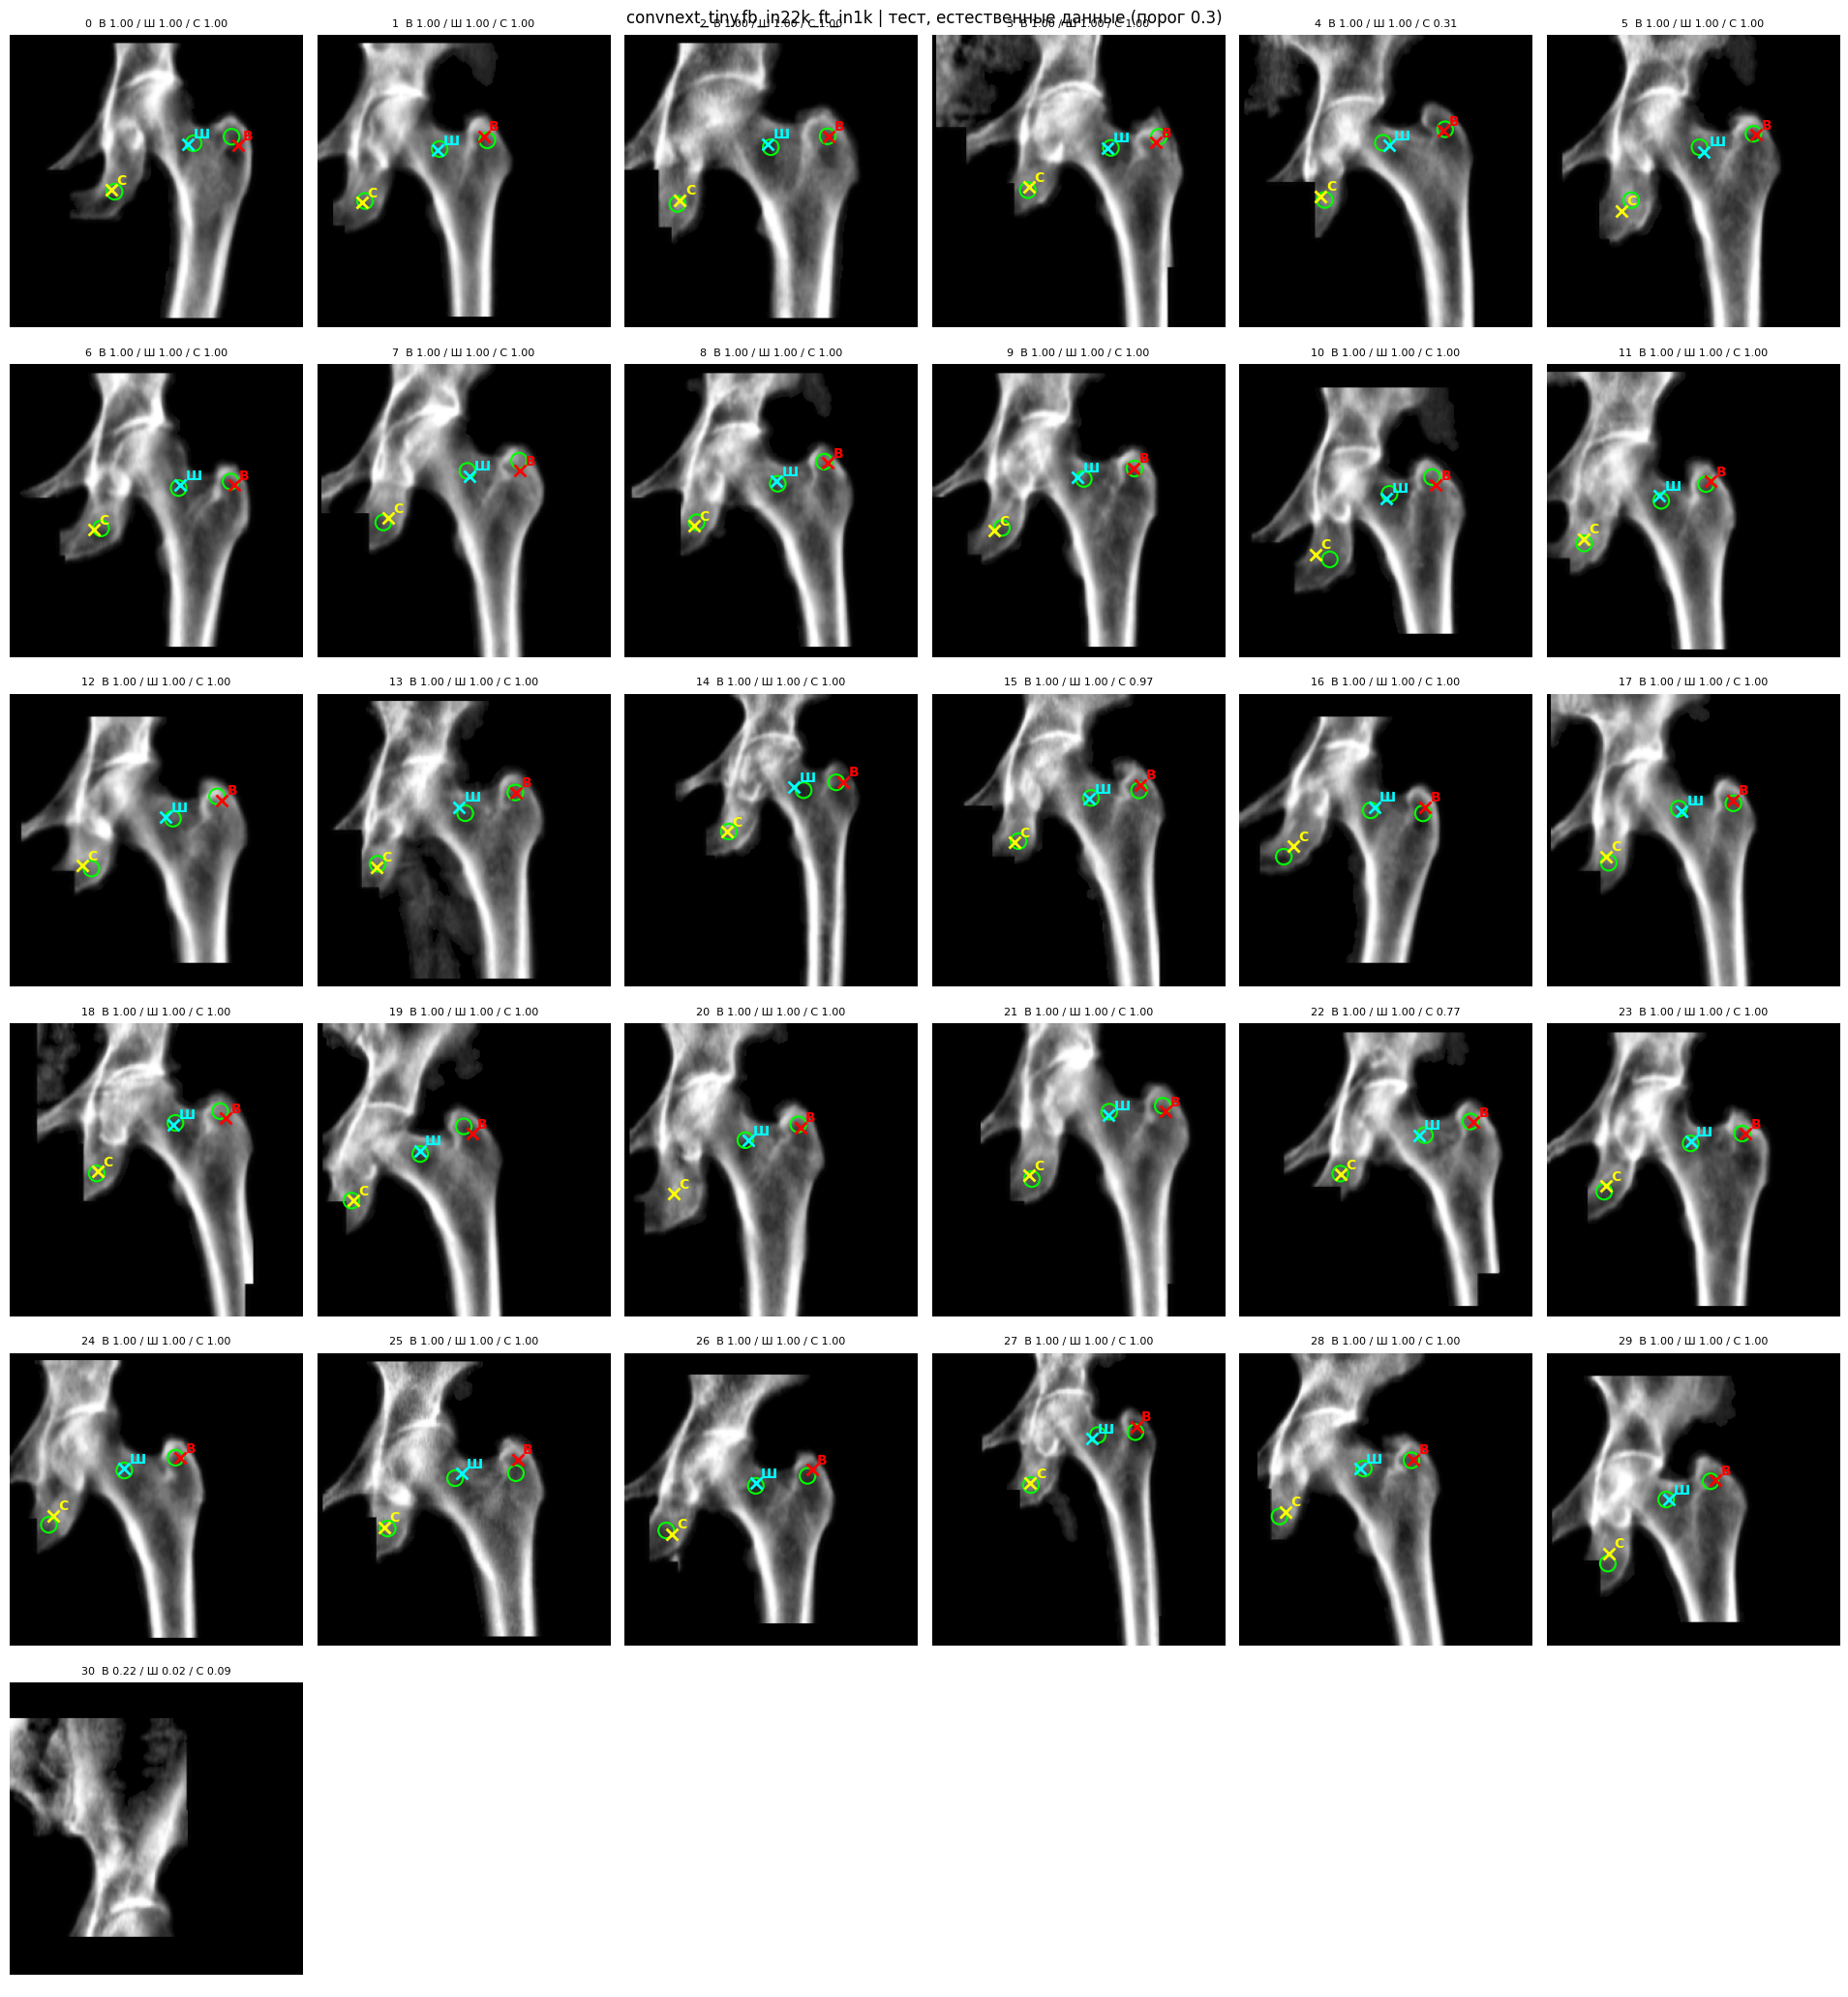

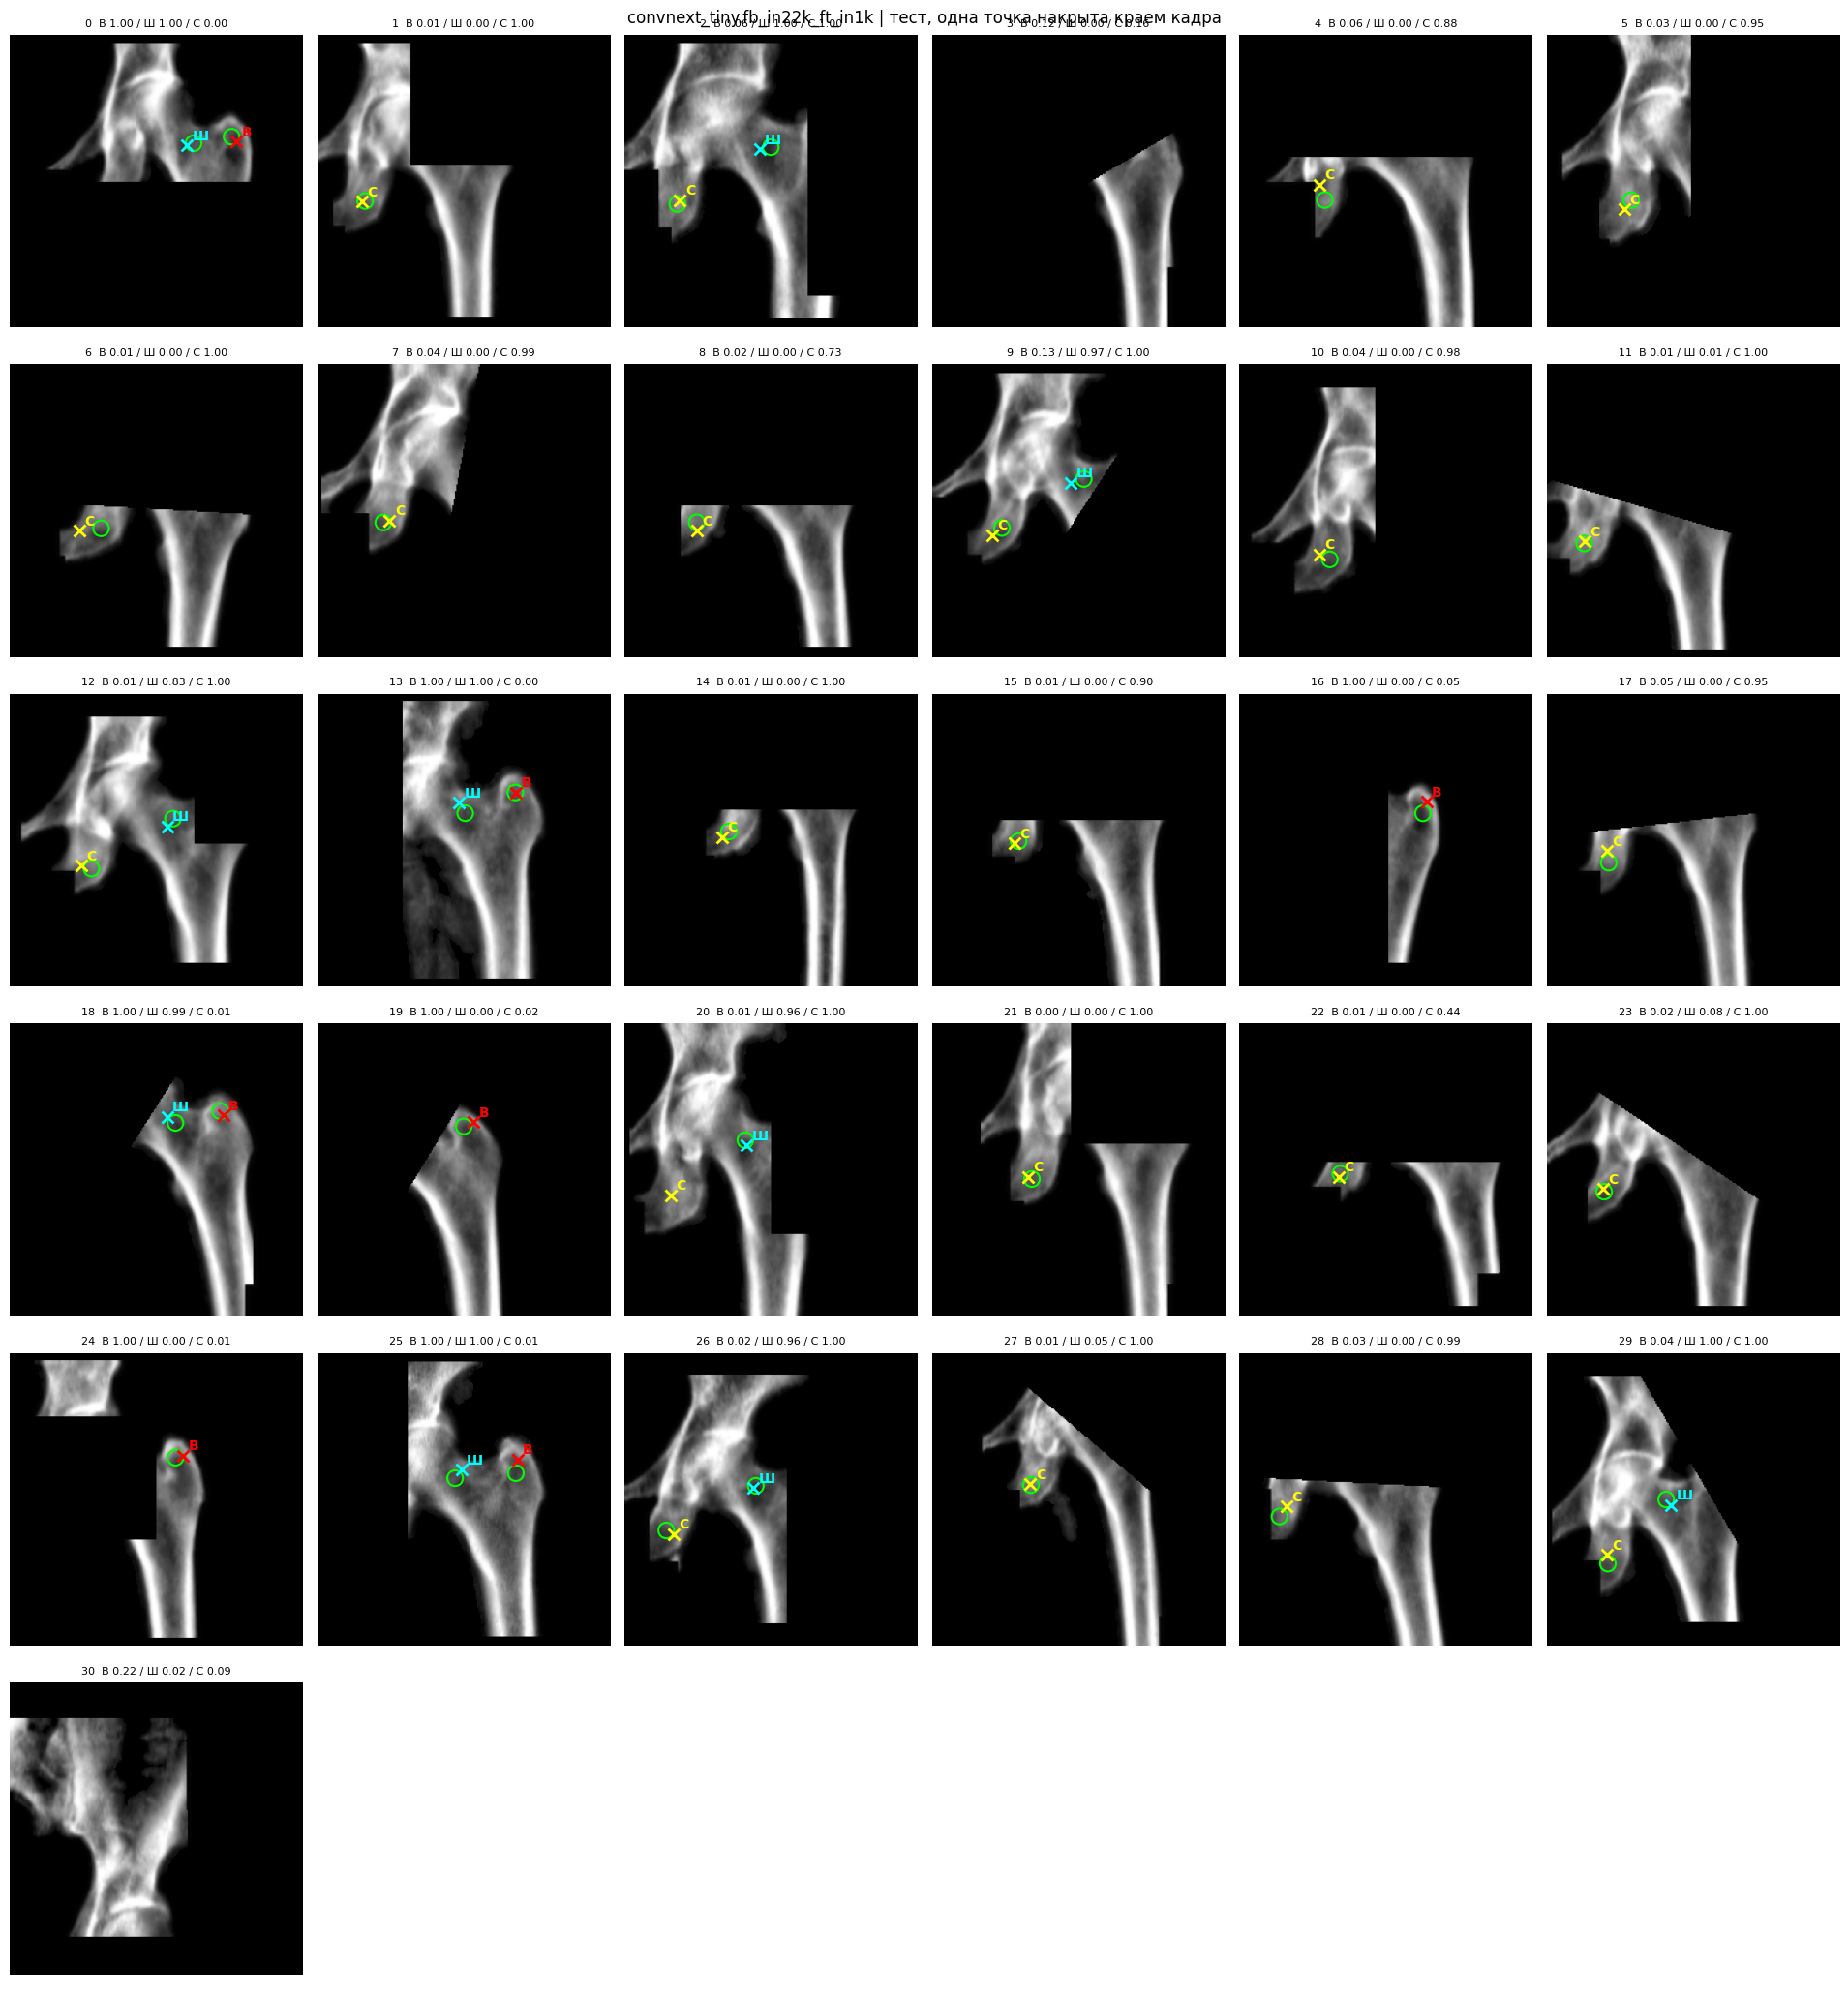

In [63]:
import matplotlib.pyplot as plt


def show_test_predictions(df: pd.DataFrame, title: str, backbone_name: str, threshold: float, force_crop: bool = False,
                          cols: int = 6, fname: str = None, show_below_threshold: bool = False):
    df_eval = force_crop_all(df) if force_crop else df
    ds = HipKeypointDataset(df_eval, IMAGES_DIR, train=False, force_crop_eval=force_crop)
    model = load_model(backbone_name)
    n = len(ds)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.5 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for i in range(n):
        image, heatmaps, coords, visible = ds[i]
        with torch.no_grad():
            hm_logits, pres_logits = model(image.unsqueeze(0).to(DEVICE))
        probs = torch.sigmoid(hm_logits)[0].cpu().numpy()
        pres = torch.sigmoid(pres_logits)[0].cpu().numpy()
        img = (image.numpy().transpose(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN)[..., 0]
        mask = bone_mask((img * 255).clip(0, 255).astype(np.uint8), ds.implant_flag(i))   # маска по входному снимку, как в collect_points
        ax = axes[i]
        ax.imshow(np.clip(img, 0, 1), cmap="gray")
        for k in range(len(KEYPOINT_NAMES)):
            y, x = np.unravel_index(np.argmax(probs[k]), probs[k].shape)
            if visible[k] == 1:
                cx, cy = coords[k].tolist()
                ax.add_patch(plt.Circle((cx, cy), 6, fill=False, color="lime", linewidth=1.5))
            found = bool(pres[k] >= threshold) and point_inside_bone(mask, x, y)  # точка "есть": голова присутствия >= порога И координата внутри маски кости
            if found or show_below_threshold:
                color = KEYPOINT_COLORS[k] if found else "gray"
                ax.plot(x, y, "x", color=color, markersize=9, markeredgewidth=2)
                ax.text(x + 4, y - 4, KEYPOINT_LETTERS[k], color=color, fontsize=10, fontweight="bold")
        ax.set_title(f"{i}  " + " / ".join(f"{KEYPOINT_LETTERS[k]} {pres[k]:.2f}" for k in range(len(KEYPOINT_NAMES))), fontsize=8)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    if fname:
        plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=110)
    plt.show()


for name in BACKBONE_CANDIDATES:
    thr = chosen_threshold[name]
    show_test_predictions(test_manifest, f"{name} | тест, естественные данные (порог {thr})", name, thr, fname=f"test_{name}.png")
    random.seed(SEED)  # накрываемая точка выбирается случайно — фиксируем: у всех backbone одни и те же
    show_test_predictions(test_manifest, f"{name} | тест, одна точка накрыта краем кадра", name, thr, force_crop=True, fname=f"test_{name}_cropped.png")

## Особые случаи: протезы и «мусорный» снимок без единой точки

Ячейка сама находит в манифесте все снимки с металлом (тот же `detect_implant`) и снимки, у которых нет ни одной размеченной точки, и прогоняет на них модель.
На картинке — то, что видит модель (чистое фото после маски кости); зелёный круг — разметка, цветной крест — предсказание при вероятности присутствия не ниже порога,
**серый крест — где стоял бы пик у отвергнутых точек** (`show_below_threshold=True`). Для снимка без точек хорошо, если крестов нет вообще (все серые).
Важно: часть этих снимков могла попасть в обучение — в таблице указано, из какого они фолда (`ОБУЧЕНИЕ` = модель их видела, оценка оптимистична).

протезов: 3, без единой точки: 1


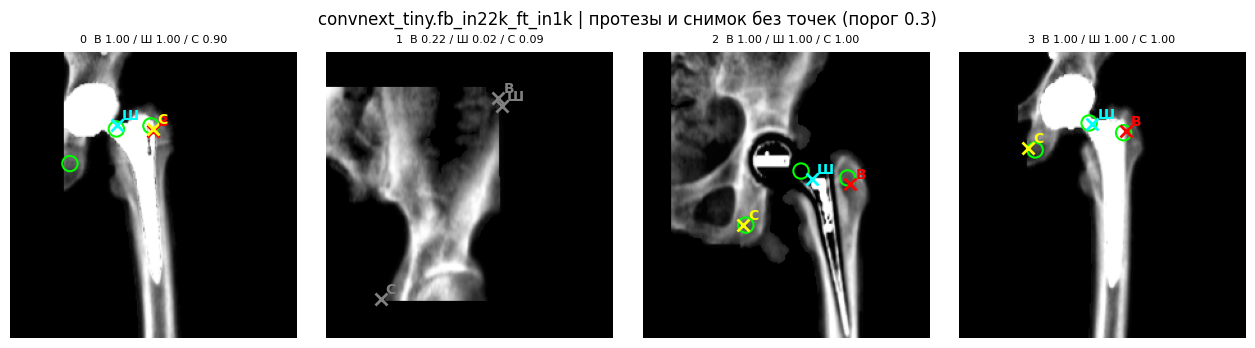


### convnext_tiny.fb_in22k_ft_in1k: решение по каждой точке (есть = голова присутствия >= порога; внутри = координата на кости)
  снимок                       что это                         фолд В: есть/внутри Ш: есть/внутри С: есть/внутри     ошибка, px
1e75f1f4                        протез ОБУЧЕНИЕ (модель его видела)          да/да          да/да          да/да 4.6, 3.1, 70.1
96d7159b нет ни одной точки (мусорный)                    валидация        нет/нет        нет/нет        нет/нет        -, -, -
6b521a34                        протез ОБУЧЕНИЕ (модель его видела)          да/да          да/да          да/да 5.1, 10.5, 2.3
952090aa                        протез ОБУЧЕНИЕ (модель его видела)          да/да          да/да          да/да  1.9, 2.6, 5.4


In [64]:
implant_files = [f for f in manifest["image_filename"]
                 if detect_implant(cv2.imread(os.path.join(IMAGES_DIR, f), cv2.IMREAD_GRAYSCALE))[0]]
no_point_files = manifest[manifest[coord_cols_flat].isna().all(axis=1)]["image_filename"].tolist()
special_df = manifest[manifest["image_filename"].isin(implant_files + no_point_files)].reset_index(drop=True)
role_of = lambda f: "протез" if f in implant_files else "нет ни одной точки (мусорный)"
fold_role = lambda fd: "тест" if int(fd) == TEST_FOLD else ("валидация" if int(fd) == VAL_FOLD else "ОБУЧЕНИЕ (модель его видела)")
print(f"протезов: {len(implant_files)}, без единой точки: {len(no_point_files)}")

for name in BACKBONE_CANDIDATES:
    thr = chosen_threshold[name]
    show_test_predictions(special_df, f"{name} | протезы и снимок без точек (порог {thr})", name, thr, cols=min(4, len(special_df)),
                          fname=f"special_{name}.png", show_below_threshold=True)
    t = collect_points(load_model(name), thr, special_df, "natural")
    print(f"\n### {name}: решение по каждой точке (есть = голова присутствия >= порога; внутри = координата на кости)")
    rows = []
    for i, r in special_df.iterrows():
        d = t.iloc[i * len(KEYPOINT_NAMES):(i + 1) * len(KEYPOINT_NAMES)]
        rows.append({"снимок": r["image_filename"][:8], "что это": role_of(r["image_filename"]), "фолд": fold_role(r["fold"]),
                     **{f"{KEYPOINT_LETTERS[k]}: есть/внутри": f"{'да' if d.iloc[k]['head'] else 'нет'}/{'да' if d.iloc[k]['head_mask'] else 'нет'}"
                        for k in range(len(KEYPOINT_NAMES))},
                     "ошибка, px": ", ".join("-" if np.isnan(e) else f"{e:.1f}" for e in d["err"])})
    print(pd.DataFrame(rows).to_string(index=False))

## Что дальше

- Веса: `hip_keypoints_<backbone>.pt` в `./outputs_hip_keypoints_v2/`; порог присутствия каждого backbone — `chosen_threshold`.
- Решение видна/не видна берите из головы присутствия (`model(x)[1]`), а не из высоты пика heatmap; положение — argmax heatmap (разрешён только в своей области).
- Сравнение с прежней моделью: те же фолды (`TEST_FOLD=4`), поэтому таблицу можно сравнить с результатом `train_hip_keypoints.ipynb`.
- Следующий шаг по схеме таза: классификатор и «математика» по вырезанной области (код `hip_roi_margins.py` уже находит край кости, верхушку вертела и седалищную кость) и голосование.

## Итоговый прогон на всех снимках бедра

Метод целиком (исходные `collect_points` и маска кости): точка берётся при оценке присутствия ≥ `THR` **и** координате внутри маски кости; снимок годен, если взяты все три точки. По ролям: обучение / валидация / тест (обучающие модель видела, поэтому честнее «валидация+тест»). Плюс синтетика (закрытая область) по формам закрытия и список проблемных снимков.

In [65]:
# Итоговый прогон метода на ВСЕХ снимках бедра. Используются исходные функции ноутбука: collect_points (голова присутствия + «внутри кости») и bone_mask.
# Решение по точке: оценка присутствия >= THR И точка внутри маски кости. Снимок годен, если взяты все три точки.
THR = 0.6                 # порог присутствия (можно менять; в ячейке калибровки выше по синтетике подобран chosen_threshold)
TOL_PX = 10.0             # точка верна, если ошибка не больше (масштаб 224; 1 px = 1.25 px исходного снимка по X)
name = BACKBONE_CANDIDATES[0]
model_all = load_model(name)
allm = manifest.reset_index(drop=True)
role = np.where(allm.image_filename.isin(test_manifest.image_filename), "тест",
                np.where(allm.image_filename.isin(val_manifest.image_filename), "валидация", "обучение"))
K = len(KEYPOINT_NAMES)

t = collect_points(model_all, THR, allm, "natural")            # строки: снимок0-точка0..2, снимок1-...
t["img"] = np.repeat(np.arange(len(allm)), K)
per = t.groupby("img").agg(good=("truth", "min"), taken=("head_mask", "all"), err_max=("err", "max"))
per["role"] = role
per["file"] = allm.image_filename.str[:8].values
per["points_ok"] = (per.good == 1) & (per.err_max <= TOL_PX)


def summarize(d):
    good, bad = d[d.good == 1], d[d.good == 0]
    return pd.Series({"снимков": len(d), "годных (3 точки размечены)": len(good),
                      "годные: взяты все три точки": f"{int(good.taken.sum())}/{len(good)}",
                      "из них ошибка <= %.0f px у всех трёх" % TOL_PX: f"{int((good.taken & good.points_ok).sum())}/{int(good.taken.sum())}",
                      "негодных (нет точек) отвергнуто": f"{int((~bad.taken).sum())}/{len(bad)}"})


table = pd.concat({**{k: summarize(per[per.role == k]) for k in ("обучение", "валидация", "тест")}, "ВСЕ": summarize(per),
                   "валидация+тест": summarize(per[per.role != "обучение"])}, axis=1)
pd.set_option("display.width", 220)
print(f"порог присутствия {THR}\n")
print(table.to_string())

print("\nСинтетика (закрытая область), снимков с закрытой точкой, у которых метод НЕ взял все три точки (хорошо = все):")
syn_rows = {}
for mode in EVAL_MODES[1:]:
    ts = collect_points(model_all, THR, allm, mode)
    ts["img"] = np.repeat(np.arange(len(allm)), K)
    p = ts.groupby("img").agg(hidden=("truth", lambda s: bool((s == 0).any())), taken=("head_mask", "all"))
    h = p[p.hidden]
    syn_rows[mode] = f"{int((~h.taken).sum())}/{len(h)}"
print(pd.Series(syn_rows).to_string())

print("\nСнимки с проблемой (годный, но не взяты все три / точка дальше допуска / негодный, но взяты все три):")
prob = per[((per.good == 1) & (~per.taken | ~per.points_ok)) | ((per.good == 0) & per.taken)]
print(prob[["file", "role", "good", "taken", "err_max"]].round(1).to_string())
per.to_csv(os.path.join(OUTPUT_DIR, "keypoints_final_metric.csv"))

порог присутствия 0.6

                                   обучение валидация   тест      ВСЕ валидация+тест
снимков                                  92        30     31      153             61
годных (3 точки размечены)               90        30     29      149             59
годные: взяты все три точки           88/90     30/30  28/29  146/149          58/59
из них ошибка <= 10 px у всех трёх    82/88     30/30  24/28  136/146          54/58
негодных (нет точек) отвергнуто         2/2       0/0    1/2      3/4            1/2

Синтетика (закрытая область), снимков с закрытой точкой, у которых метод НЕ взял все три точки (хорошо = все):
strip      153/153
rect       153/153
oblique    152/153
wedge      152/153

Снимки с проблемой (годный, но не взяты все три / точка дальше допуска / негодный, но взяты все три):
         file      role  good  taken  err_max
img                                          
1    bc8f2259  обучение     1   True     11.3
13   b30b63d4      тест     1  False  

## Отрисовка после всех фильтров

Исходная `show_test_predictions` (теперь крест только у точки, прошедшей порог **и** проверку «внутри кости»): подозрительные по метрикам (сначала большие ошибки), случайные из остальных и синтетика с закрытой областью. Зелёный круг — разметка.

подозрительных: 14


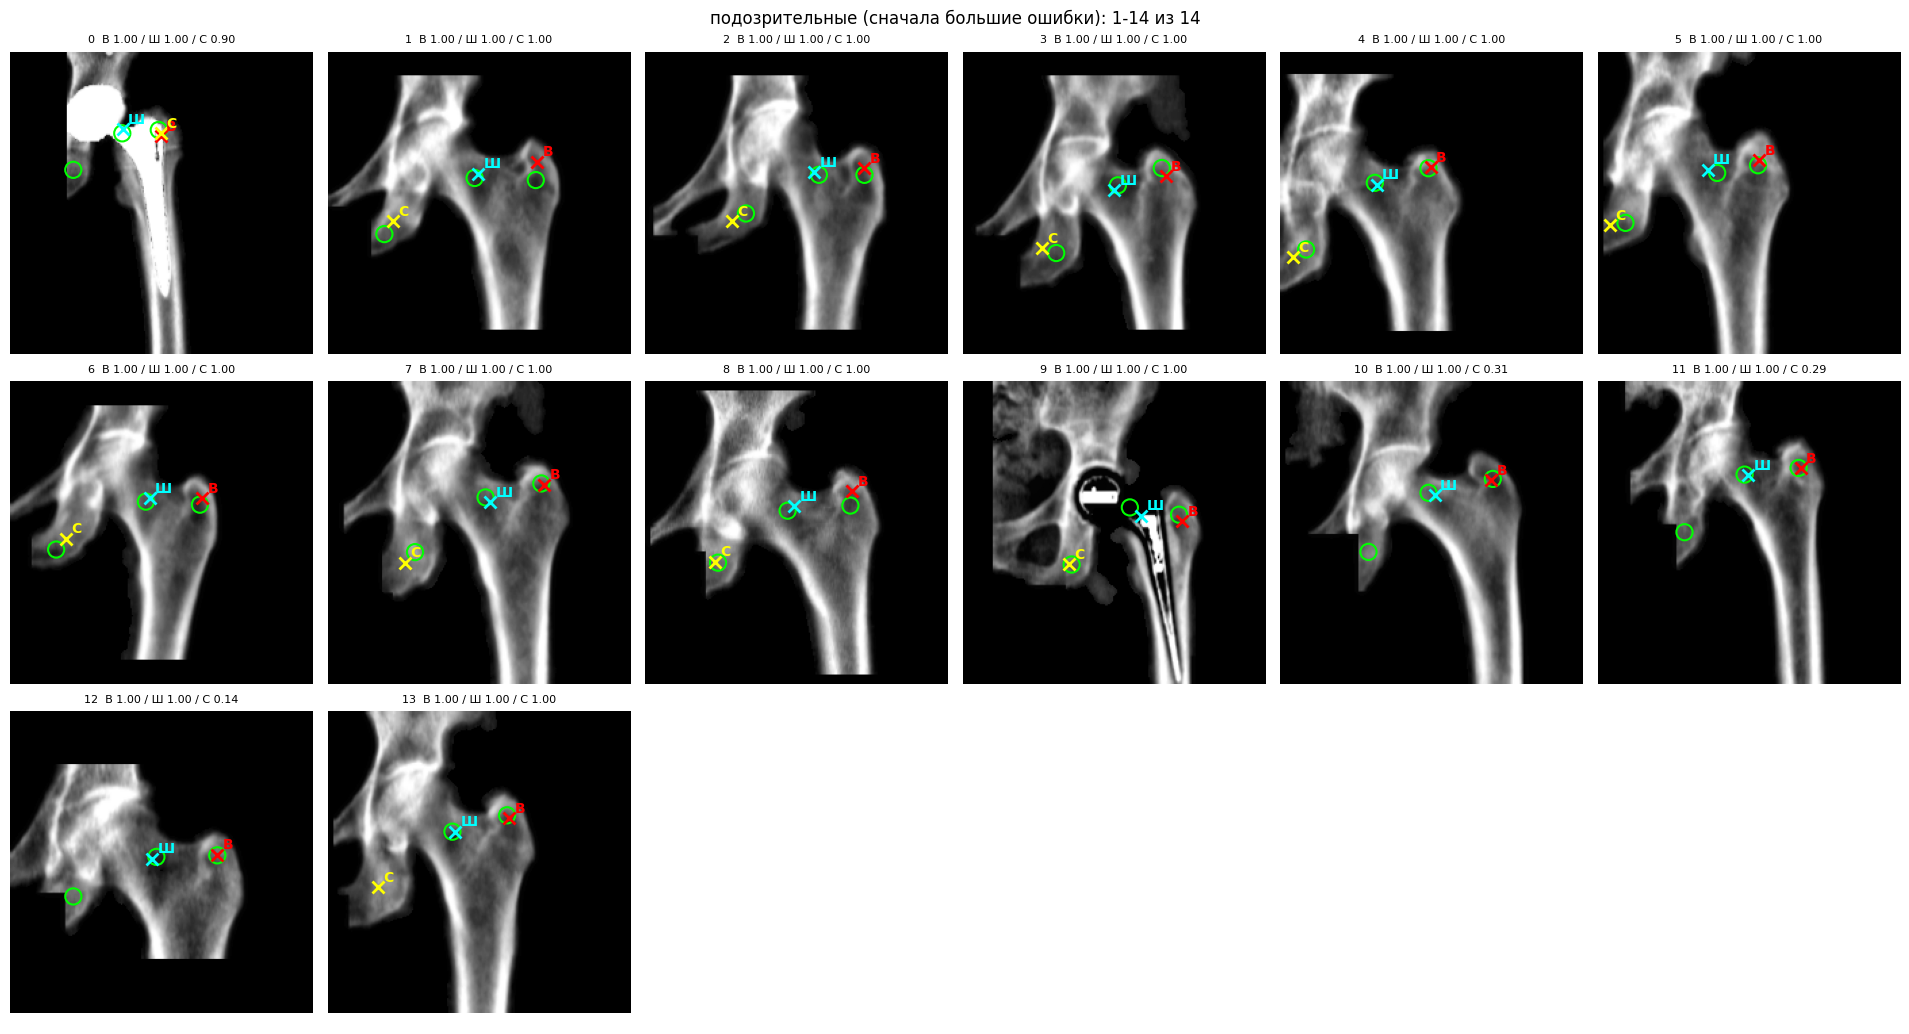

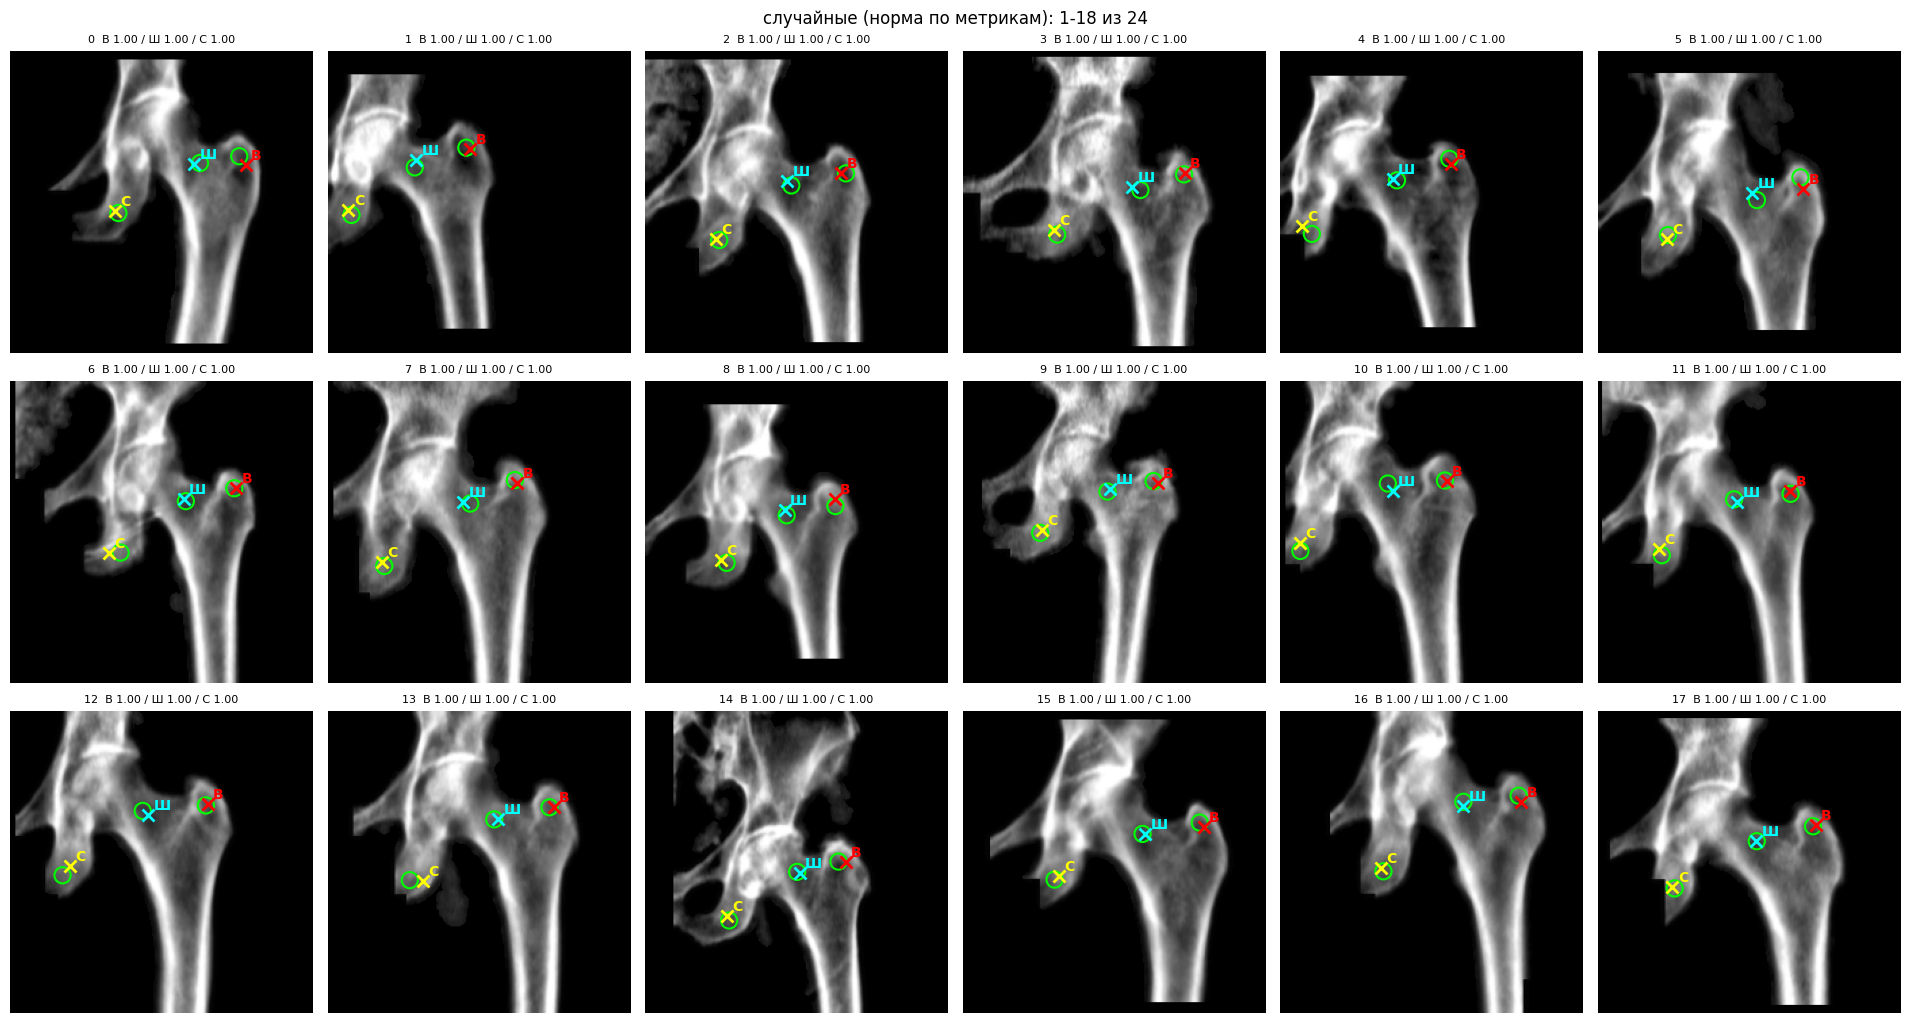

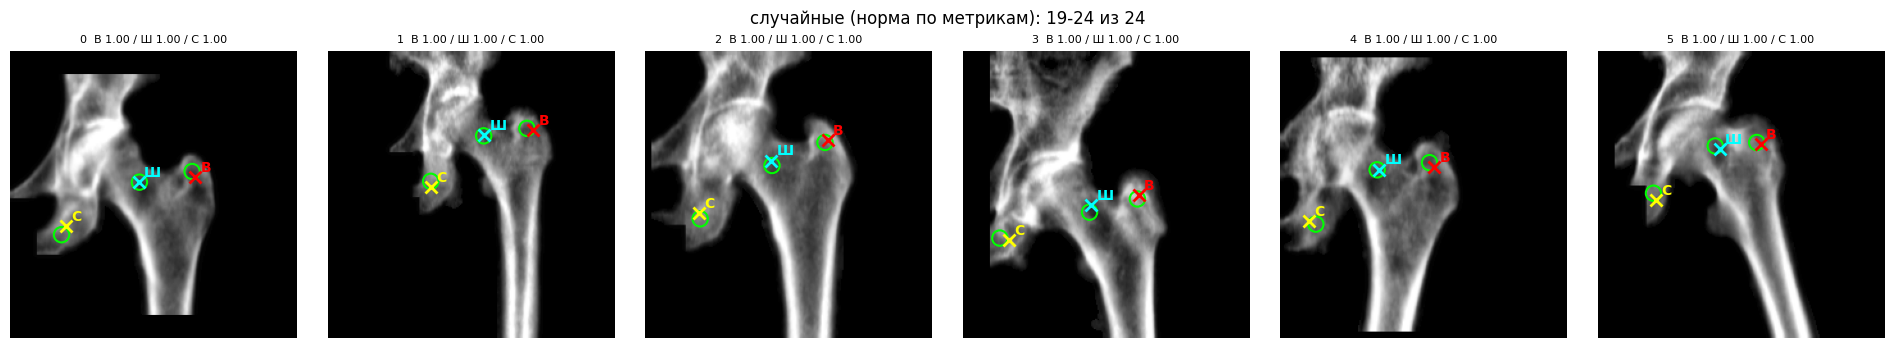

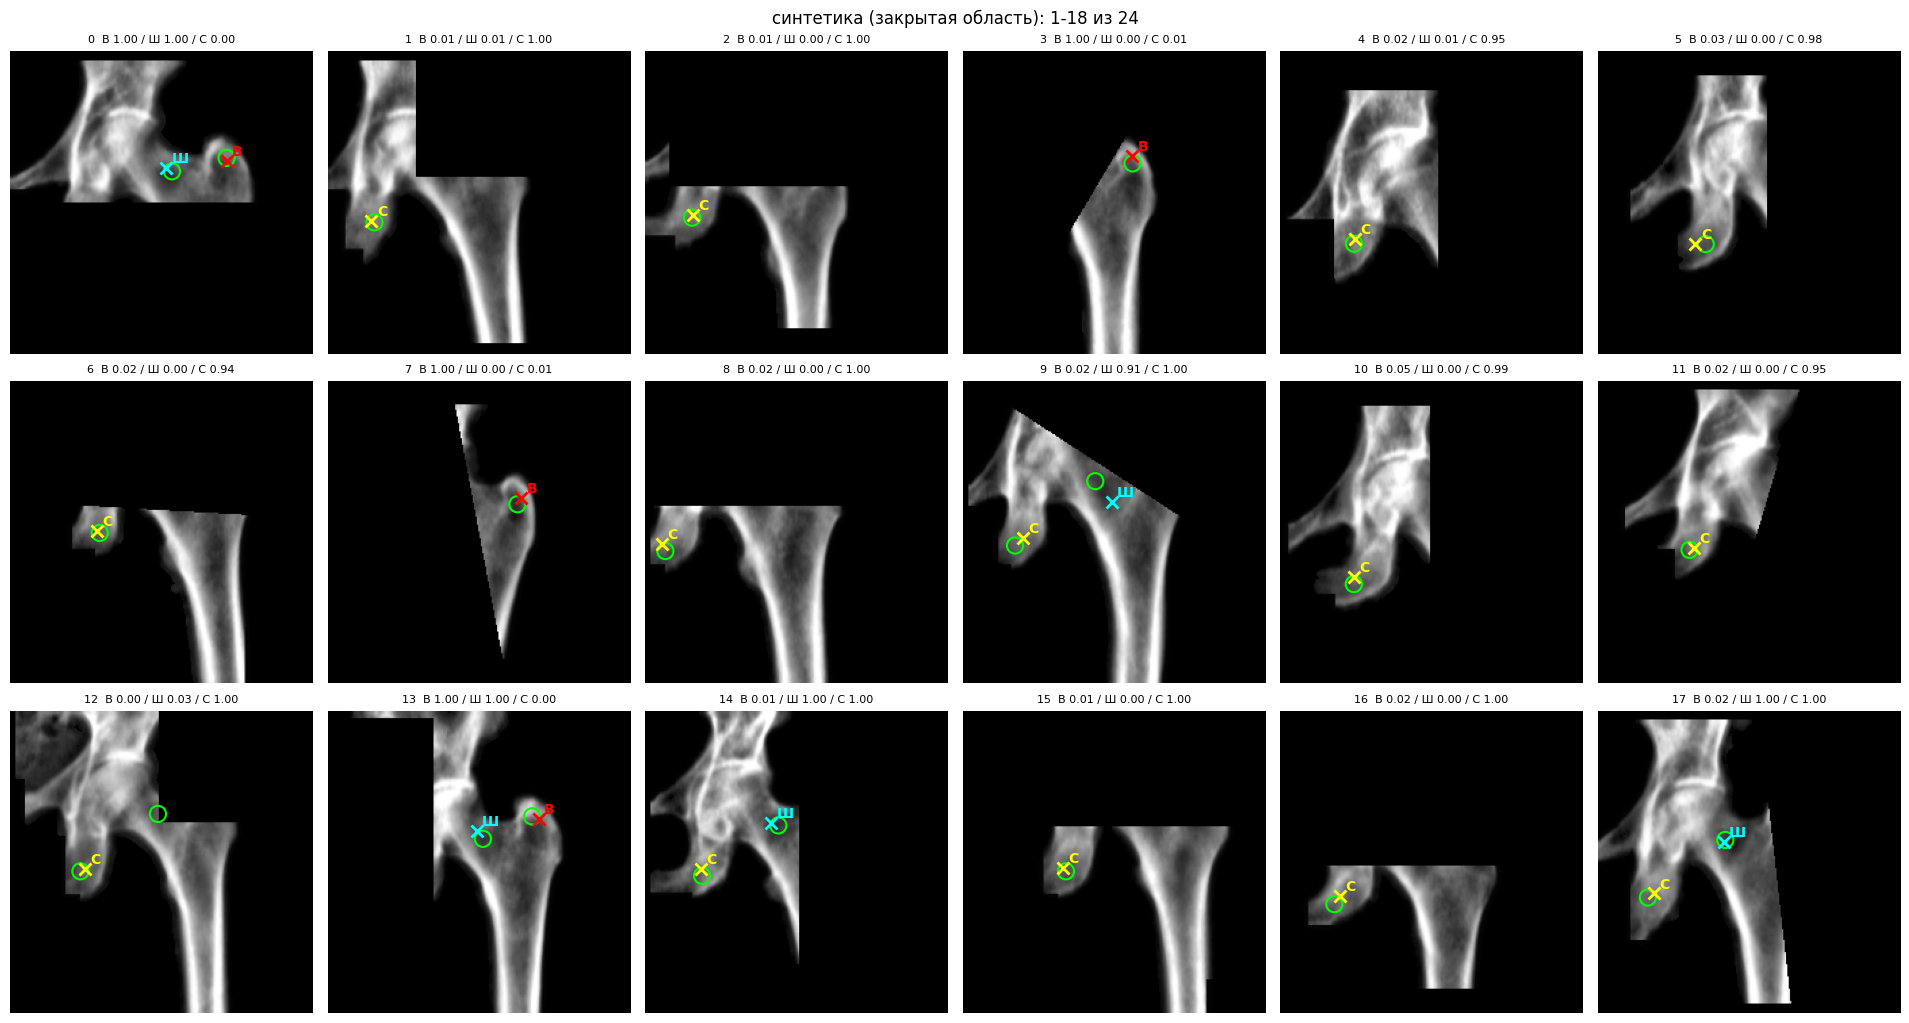

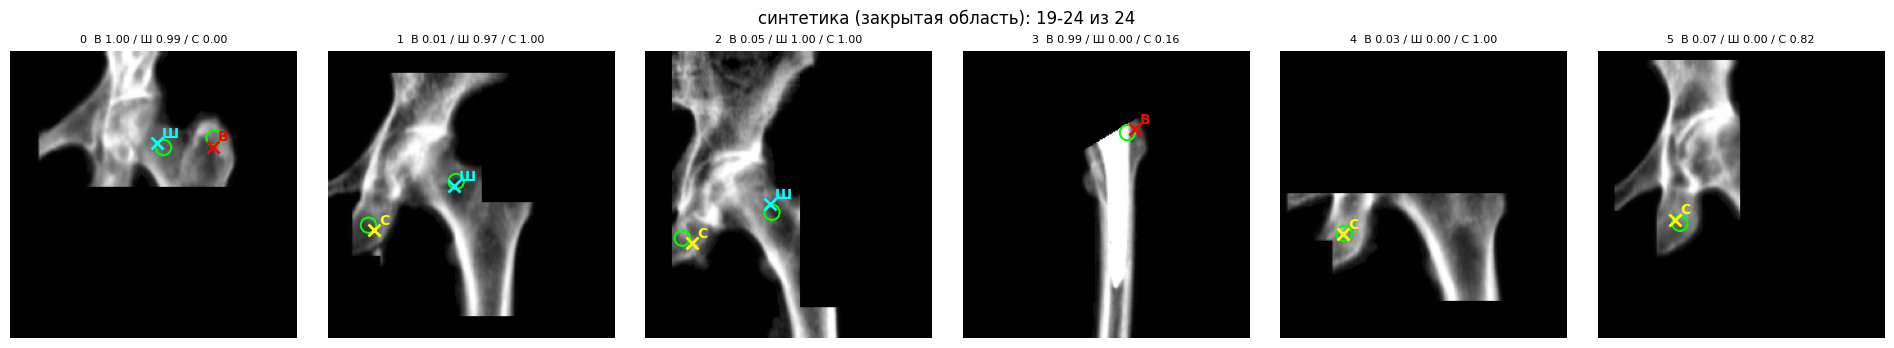

In [66]:
# Отрисовка после всех фильтров (исходная show_test_predictions): крест рисуется только у точки, у которой оценка присутствия >= порога И точка внутри маски кости.
# Зелёный круг — разметка, цветной крест — точка модели (В, Ш, С). Снимок показан целиком. Нужна предыдущая ячейка (per, allm, THR, name).
def draw_batches(idx, title, force_crop=False, per_page=18):
    for s in range(0, len(idx), per_page):
        sub = allm.iloc[list(idx[s:s + per_page])].reset_index(drop=True)
        random.seed(SEED)                                        # накрываемая точка в синтетике случайна, но одна и та же для предсказания и рисунка (внутри одного вызова)
        show_test_predictions(sub, f"{title}: {s + 1}-{s + len(sub)} из {len(idx)}", name, THR, force_crop=force_crop, cols=6,
                              fname=f"vis_{title.split()[0]}_{s // per_page + 1}.png")


rng = np.random.default_rng(0)
sus = per[((per.good == 1) & (~per.taken | ~per.points_ok)) | ((per.good == 0) & per.taken)].copy()
sus["_k"] = sus.err_max.fillna(1e9)
sus_idx = sus.sort_values("_k", ascending=False).index.tolist()
rest = per.index.difference(sus.index).tolist()
rand_idx = sorted(rng.choice(rest, size=min(24, len(rest)), replace=False).tolist()) if rest else []
syn_idx = sorted(rng.choice(len(allm), size=min(24, len(allm)), replace=False).tolist())

print(f"подозрительных: {len(sus_idx)}")
draw_batches(sus_idx, "подозрительные (сначала большие ошибки)")
draw_batches(rand_idx, "случайные (норма по метрикам)")
draw_batches(syn_idx, "синтетика (закрытая область)", force_crop=True)